In [1]:
# Collected html content from web in html format by using selenium
# now going to fetch required data from that html content

# Getting HTML file
with open('smartpix.html','r', encoding = 'utf-8') as f:
  html = f.read()

In [2]:
# Getting important libraries

import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import time
from bs4 import BeautifulSoup

In [3]:
# converting html file into html parsing to fetch data

soup = BeautifulSoup(html,'lxml')


In [4]:
# Feching desired data
divs = soup.find_all('div',class_='sm-product has-tag has-features has-actions')

In [5]:
phone_name = []
price = []
connectivity = []
processor = []
Ram_Rom = []
battery = []
size_and_display = []
camera = []
os = []

for phone in divs:

# Getting product name
  try:
    name = phone.find('h2').text.strip()
    phone_name.append(name)
  except:
    phone.append(None)

# getting product price
  try:
    pr = phone.find('span',class_='price').text.strip()
    price.append(pr)
  except:
    price.append(None)

# Fetching Details
  try:
    ul = phone.find('ul',class_='sm-feat specs')
    lists = ul.find_all('li')
    t = lists[0].text.strip()
    connectivity.append(t)
  except:
    connectivity.append(None)

# extracting processor Details
  try:
    ul_ = phone.find('ul',class_='sm-feat specs')
    all_lists = ul_.find_all('li')
    details = all_lists[1].text.strip()
    processor.append(details)
  except:
    processor.append(None)

# extracting RAM and ROM Details
  try:
    ram = all_lists[2].text.strip()
    Ram_Rom.append(ram)
  except:
    Ram_Rom.append(None)

# extracting battery and charging Details
  try:
    batt = all_lists[3].text.strip()
    battery.append(batt)
  except:
    battery.append(None)

# extracting display Details
  try:
    size = all_lists[4].text.strip()
    size_and_display.append(size)
  except:
    size_and_display.append(None)

# extracting camera Details
  try:
    cam = all_lists[5].text.strip()
    camera.append(cam)
  except:
    camera.append(None)

# extracting android version Details
  try:
    version = all_lists[7].text.strip()
    os.append(version)
  except:
    os.append(None)


# generating Dataframe with fetched data

dataset = pd.DataFrame({
    'phone_name' :phone_name,
    'price' :price,
    'connectivity':connectivity,
    'processor' :processor,
    'Ram_Rom' :Ram_Rom,
    'battery' :battery,
    'size_and_display' :size_and_display,
    'camera' :camera,
    'os' :os
    })

In [6]:
# Preview of dataset
dataset.head()

,phone_name,price,connectivity,processor,Ram_Rom,battery,size_and_display,camera,os
0,Vivo V60 5G,"₹36,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android v15
1,Motorola Moto G86 Power 5G,"₹17,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v15
2,OnePlus Nord CE 5 5G,"₹24,998","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android v15
3,Poco M7 Plus 5G,"₹13,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 6s Gen3, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android v15
4,Xiaomi Redmi Note 14 SE 5G,"₹14,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7025 Ultra, Octa Core, 2.5 GHz Proce...","6 GB RAM, 128 GB inbuilt",5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v15


In [7]:
# Converting given dataset into csv format
dataset.to_csv('uncleaned_smartprix_data.csv')

In [8]:
# making a copy
df = dataset.copy()
df.head()

,phone_name,price,connectivity,processor,Ram_Rom,battery,size_and_display,camera,os
0,Vivo V60 5G,"₹36,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android v15
1,Motorola Moto G86 Power 5G,"₹17,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v15
2,OnePlus Nord CE 5 5G,"₹24,998","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android v15
3,Poco M7 Plus 5G,"₹13,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 6s Gen3, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android v15
4,Xiaomi Redmi Note 14 SE 5G,"₹14,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7025 Ultra, Octa Core, 2.5 GHz Proce...","6 GB RAM, 128 GB inbuilt",5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v15


# ***Data Discription:-***
- This data is all about smartphones. this data is uncleaned and messy.
- it contains generally information about smartphones with it's specifications such as model name, RAM, ROM, processor, battery life, camera details in pixel, and it's android version

# ***Column Discription:-***
1. ***phone_name*** - in general it describes the name of particular phones
2. ***price*** - it contains the price of that phone in rupees.
3. ***connectivity*** - it contains details about connectivity, such as is it dual or single sim or is it 3G, 4G or 5G phone.
4. ***processor*** - which kind of processor is used in that phone.
5. ***Ram_Rom*** - information about RAM and ROM.
6. ***battery*** - info about battery life in mAh.
7. ***size_and_display*** - contains the size of phone in inch and info about display.
8. ***camera*** - consists the inforamtion about front and rear camera in Mega Pixel.
9. ***os*** - Finally the operating system of that phone

***Convering Data into two types...***


# ***Dirty Data:-***

1. In phone name column the info about Ram and Rom is with phone name in some rows. ----- ***Correctness***
2. Again in phone name column it consits the feature phones along with smartphones. such as rwo no:- 999,983,977,973,966,962,955,934,898,899,874,872,866,859,848,849,852,787,788,782,767,766,752,753,767,725,746,718,719,723,681 etc. ----- ***Invalid***
3. in price column the price is fluctuaing, such as in row no. 640 the price of phone is 499. ----- ***Consistancy***
4. in connectivity column in some rows IR Blaster and NFC is missing. ---- ***Completeness***
5. As per my observation the price of feature phone is starting from 4500 rs. ------ ***Consistency***
6. in processor column thers is battery details is added instead of processor in some rows, but it only for feature phones. ----- ***Invalid***
7. In android version column sometime bluetooth, no FM radio, and memory card not supported is written instead of android version in some rows.------ ***Invalid***
8. again in price column symbol of rupees '₹' is written infront of price.------ ***Invalid***
9. Null Values in os ----- ***Compliteness***





# ***Messy Data:-***
1. phone name contians two values such as phone name and Ram and Rom
2. in price column the price is not in specific format. i mean in price it contains '₹' and ','
3. connectivity column contains multiple values
4. processor column contains multiple values.
5. again in ram_rom column conatins two values
6. battery column contains multiple values.
7. size and display column contains multiple values
8. the dtype of price column is object


In [9]:
# Checking Duplicate values
df.duplicated().sum()

# Removing Duplicate values
df = df.drop_duplicates()


In [10]:
# Fetching Details from android version
df['os'] = df['os'].str.split(' ').str.get(0)
df['os'] = df['os'].where(df['os'].isin(['Android', 'iOS']), None)

In [11]:

# Starting with phone name column
# Seperating Ram and Rom information along with phone name
# we are using regular expressions

df['phone_name'] = df['phone_name'].str.replace(r'5G|\(.*?\)|4G|\b\d+GB\b|\b\d+TB\b|\b\d+G\b|5G|4G|Snapdragon', '', regex=True)
df.head(5)

,phone_name,price,connectivity,processor,Ram_Rom,battery,size_and_display,camera,os
0,Vivo V60,"₹36,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android
1,Motorola Moto G86 Power,"₹17,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android
2,OnePlus Nord CE 5,"₹24,998","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android
3,Poco M7 Plus,"₹13,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 6s Gen3, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android
4,Xiaomi Redmi Note 14 SE,"₹14,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7025 Ultra, Octa Core, 2.5 GHz Proce...","6 GB RAM, 128 GB inbuilt",5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android


In [12]:
# Seperating brand name from this dataset

df['brand']=df['phone_name'].str.split(' ').str.get(0)
df.head()

,phone_name,price,connectivity,processor,Ram_Rom,battery,size_and_display,camera,os,brand
0,Vivo V60,"₹36,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo
1,Motorola Moto G86 Power,"₹17,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola
2,OnePlus Nord CE 5,"₹24,998","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus
3,Poco M7 Plus,"₹13,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 6s Gen3, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android,Poco
4,Xiaomi Redmi Note 14 SE,"₹14,999","Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7025 Ultra, Octa Core, 2.5 GHz Proce...","6 GB RAM, 128 GB inbuilt",5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi


In [13]:
# Now With Price Column

df['price']=df['price'].str.replace('₹','').str.replace(',','')

In [14]:
# Now as per my observation the price of feature phones is starting from 4500 rs.
# so we can easily exclude feature phones according to its price

# Converting price column into int

df['price'] =df['price'].astype('int')

# fetching only required data

df = df[df['price'] >= 4500 ]
df.sample(12)

,phone_name,price,connectivity,processor,Ram_Rom,battery,size_and_display,camera,os,brand
161,Infinix Hot 60,10499,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7020, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5200 mAh Battery with 18W Fast Charging,"6.7 inches, 720 x 1600 px, 120 Hz Display with...",50 MP + Depth Sensor Dual Rear & 8 MP Front Ca...,Android,Infinix
390,iQOO Z9x,13499,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 6 Gen1, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 44W Fast Charging,"6.72 inches, 1080 x 2408 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Android,iQOO
78,Google Pixel 9A,41660,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Tensor G4, Octa Core, 3.1 GHz Processor","8 GB RAM, 256 GB inbuilt",5100 mAh Battery with 23W Fast Charging,"6.3 inches, 1080 x 2424 px, 120 Hz Display wit...",48 MP + 13 MP Dual Rear & 13 MP Front Camera,Android,Google
448,Motorola Moto G62,10999,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 695, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with Fast Charging,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,Android,Motorola
486,Samsung Galaxy Z Fold 7,174999,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 512 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",Android,Samsung
230,OPPO Reno 14,42998,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350, Octa Core, 3.35 GHz Processor","12 GB RAM, 512 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,None,OPPO
252,OnePlus 13R,47999,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.78 inches, 1264 x 2780 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 16 MP Front...,Android,OnePlus
335,Samsung Galaxy M36,21999,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Exynos 1380, Octa Core, 2.4 GHz Processor","8 GB RAM, 256 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 8 MP + 2 MP Triple Rear & 13 MP Front ...,Android,Samsung
763,Samsung Galaxy S24,89999,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Exynos 2400, Deca Core, 3.2 GHz Processor","8 GB RAM, 512 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,None,Samsung
802,Motorola Moto G73,12999,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 930, Octa Core, 2.2 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 30W Fast Charging,"6.5 inches, 1080 x 2400 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,Motorola


In [15]:

# fetching details from connectivity column

df['sim_supported'] = df['connectivity'].str.split(',').str.get(0)

# now adding one more column in df as generation and only taking 5G
df['generation'] = df['connectivity'].str.split(',').str.get(3).str.findall(r"\d").str.get(0)

# deleting connectivity column permanatly
df.drop(columns='connectivity',inplace=True)

df.head()

,phone_name,price,processor,Ram_Rom,battery,size_and_display,camera,os,brand,sim_supported,generation
0,Vivo V60,36999,"Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Dual Sim,5
1,Motorola Moto G86 Power,17999,"Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dual Sim,5
2,OnePlus Nord CE 5,24998,"Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dual Sim,5
3,Poco M7 Plus,13999,"Snapdragon 6s Gen3, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android,Poco,Dual Sim,5
4,Xiaomi Redmi Note 14 SE,14999,"Dimensity 7025 Ultra, Octa Core, 2.5 GHz Proce...","6 GB RAM, 128 GB inbuilt",5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dual Sim,5


In [16]:
# Extracting processor details
# Mobile Processor column
df['mobile_processor'] = df['processor'].str.split(',').str.get(0)

# seperate core column
df['core'] = df['processor'].str.split(',').str.get(1)

# seperate gigahertz column
df['gigahertz'] =  df['processor'].str.split(',').str.get(2).str.findall(r"\d\.\d+").str.get(0)

# deleting processor column permanataly
df.drop(columns = 'processor',inplace=True)

df.head()

,phone_name,price,Ram_Rom,battery,size_and_display,camera,os,brand,sim_supported,generation,mobile_processor,core,gigahertz
0,Vivo V60,36999,"8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Dual Sim,5,Snapdragon 7 Gen4,Octa Core,2.8
1,Motorola Moto G86 Power,17999,"8 GB RAM, 128 GB inbuilt",6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dual Sim,5,Dimensity 7400,Octa Core,2.6
2,OnePlus Nord CE 5,24998,"8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dual Sim,5,Dimensity 8350 Apex,Octa Core,3.35
3,Poco M7 Plus,13999,"6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android,Poco,Dual Sim,5,Snapdragon 6s Gen3,Octa Core,2.3
4,Xiaomi Redmi Note 14 SE,14999,"6 GB RAM, 128 GB inbuilt",5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dual Sim,5,Dimensity 7025 Ultra,Octa Core,2.5


In [17]:
# Again fetching Details from such As RAM and ROM from Ram_Rom column

# Creating RAM Column
df['RAM']=  df['Ram_Rom'].str.split(',').str.get(0).str.findall(r"\d+").str.get(0)

# # Creating ROM column
df['ROM']=  df['Ram_Rom'].str.split(',').str.get(1).str.findall(r"\d+").str.get(0)

# deleting Ram_Rom cloumn permanantely
df.drop(columns='Ram_Rom',inplace=True)


df.head()

,phone_name,price,battery,size_and_display,camera,os,brand,sim_supported,generation,mobile_processor,core,gigahertz,RAM,ROM
0,Vivo V60,36999,6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Dual Sim,5,Snapdragon 7 Gen4,Octa Core,2.8,8,128
1,Motorola Moto G86 Power,17999,6720 mAh Battery with 33W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dual Sim,5,Dimensity 7400,Octa Core,2.6,8,128
2,OnePlus Nord CE 5,24998,7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dual Sim,5,Dimensity 8350 Apex,Octa Core,3.35,8,128
3,Poco M7 Plus,13999,7000 mAh Battery with 33W Fast Charging,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android,Poco,Dual Sim,5,Snapdragon 6s Gen3,Octa Core,2.3,6,128
4,Xiaomi Redmi Note 14 SE,14999,5110 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dual Sim,5,Dimensity 7025 Ultra,Octa Core,2.5,6,128


In [18]:
# Again Fetching Battery details
# Creating new column as battery_in_mAh

df['battery_in_mAh'] = df['battery'].str.findall(r"\d{4}").str.get(0)

# Creating new column as charging Support
df['charging_support_in_watt']=df['battery'].str.findall(r"\d+W").str.get(0).str.replace('W','')


# deleting charging_support and battery column permanantely

df.drop(columns=['battery'],inplace=True)

df.head()

,phone_name,price,size_and_display,camera,os,brand,sim_supported,generation,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt
0,Vivo V60,36999,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Dual Sim,5,Snapdragon 7 Gen4,Octa Core,2.8,8,128,6500,90
1,Motorola Moto G86 Power,17999,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dual Sim,5,Dimensity 7400,Octa Core,2.6,8,128,6720,33
2,OnePlus Nord CE 5,24998,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dual Sim,5,Dimensity 8350 Apex,Octa Core,3.35,8,128,7100,80
3,Poco M7 Plus,13999,"6.9 inches, 1080 x 2340 px, 144 Hz Display wit...",50 MP Rear & 8 MP Front Camera,Android,Poco,Dual Sim,5,Snapdragon 6s Gen3,Octa Core,2.3,6,128,7000,33
4,Xiaomi Redmi Note 14 SE,14999,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dual Sim,5,Dimensity 7025 Ultra,Octa Core,2.5,6,128,5110,45


In [19]:
# Fetching Display size
# getting phone size in inch
df['size_in_inch'] = df['size_and_display'].str.split(',').str.get(0).str.split(' ').str.get(0)

# fetching refresh_rate of display
df['refresh_rate'] =  df['size_and_display'].str.split(',').str.get(2).str.split(' ').str.get(1)

# deleting size and display column permanantely
df.drop(columns = 'size_and_display',inplace=True)
df.head()

,phone_name,price,camera,os,brand,sim_supported,generation,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate
0,Vivo V60,36999,50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Dual Sim,5,Snapdragon 7 Gen4,Octa Core,2.8,8,128,6500,90,6.77,120
1,Motorola Moto G86 Power,17999,50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dual Sim,5,Dimensity 7400,Octa Core,2.6,8,128,6720,33,6.7,120
2,OnePlus Nord CE 5,24998,50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dual Sim,5,Dimensity 8350 Apex,Octa Core,3.35,8,128,7100,80,6.77,120
3,Poco M7 Plus,13999,50 MP Rear & 8 MP Front Camera,Android,Poco,Dual Sim,5,Snapdragon 6s Gen3,Octa Core,2.3,6,128,7000,33,6.9,144
4,Xiaomi Redmi Note 14 SE,14999,50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dual Sim,5,Dimensity 7025 Ultra,Octa Core,2.5,6,128,5110,45,6.67,120


In [20]:
# Deleting Unwanted column
df.drop(columns=['sim_supported'],inplace=True)

In [21]:
# Applying some changes in generation and mobile processor column
# df['has_5G'] = df['generation'].str.replace('5','True')
# df['has_5G'] = df['has_5G'].fillna('False')

# making an function to detect that particular phone id 5g or not

def five (text):
  if text == '5':
    return True
  else:
    return False


df['has_5G'] = df['generation'].apply(five)




In [22]:
# Processor column
df['mobile_processor'] = df['mobile_processor'].str.split(' ').str.get(0)

In [23]:
# Deleting Unwanted column
df.drop(columns=['generation'],inplace=True)

In [24]:
# fetching required details from camera column
df['front_camera_in_megapixel'] = df['camera'].str.split('&').str.get(1).str.findall(r"\d+").str.get(0)
df['rear_camera'] = df['camera'].str.split('&').str.get(0).str.findall(r"\d+\s*MP")
df.head()

,phone_name,price,camera,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera
0,Vivo V60,36999,50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Snapdragon,Octa Core,2.8,8,128,6500,90,6.77,120,True,50,"[50 MP, 50 MP, 8 MP]"
1,Motorola Moto G86 Power,17999,50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dimensity,Octa Core,2.6,8,128,6720,33,6.7,120,True,32,"[50 MP, 8 MP]"
2,OnePlus Nord CE 5,24998,50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dimensity,Octa Core,3.35,8,128,7100,80,6.77,120,True,16,"[50 MP, 8 MP]"
3,Poco M7 Plus,13999,50 MP Rear & 8 MP Front Camera,Android,Poco,Snapdragon,Octa Core,2.3,6,128,7000,33,6.9,144,True,8,[50 MP]
4,Xiaomi Redmi Note 14 SE,14999,50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dimensity,Octa Core,2.5,6,128,5110,45,6.67,120,True,20,"[50 MP, 8 MP, 2 MP]"


In [25]:
# making a functon for extrcting no. of cameras

def total_length (text):
  if text is None:
    return 0
  else:
    return len(text)


In [26]:
df['rear_camera'] = df['rear_camera'].apply(total_length)
df.head()

,phone_name,price,camera,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera
0,Vivo V60,36999,50 MP + 50 MP + 8 MP Triple Rear & 50 MP Front...,Android,Vivo,Snapdragon,Octa Core,2.8,8,128,6500,90,6.77,120,True,50,3
1,Motorola Moto G86 Power,17999,50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android,Motorola,Dimensity,Octa Core,2.6,8,128,6720,33,6.7,120,True,32,2
2,OnePlus Nord CE 5,24998,50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android,OnePlus,Dimensity,Octa Core,3.35,8,128,7100,80,6.77,120,True,16,2
3,Poco M7 Plus,13999,50 MP Rear & 8 MP Front Camera,Android,Poco,Snapdragon,Octa Core,2.3,6,128,7000,33,6.9,144,True,8,1
4,Xiaomi Redmi Note 14 SE,14999,50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android,Xiaomi,Dimensity,Octa Core,2.5,6,128,5110,45,6.67,120,True,20,3


In [27]:
# removing unwanted columns
df.drop(columns=['camera'],inplace=True)



# Again 

In [28]:

# Checking Dtype of Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 934 entries, 0 to 1019
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   phone_name                 934 non-null    object
 1   price                      934 non-null    int64 
 2   os                         665 non-null    object
 3   brand                      934 non-null    object
 4   mobile_processor           934 non-null    object
 5   core                       931 non-null    object
 6   gigahertz                  832 non-null    object
 7   RAM                        934 non-null    object
 8   ROM                        931 non-null    object
 9   battery_in_mAh             933 non-null    object
 10  charging_support_in_watt   877 non-null    object
 11  size_in_inch               934 non-null    object
 12  refresh_rate               842 non-null    object
 13  has_5G                     934 non-null    bool  
 14  front_camera_i

In [29]:
df1 = df.copy()

In [30]:
df1.head()

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera
0,Vivo V60,36999,Android,Vivo,Snapdragon,Octa Core,2.8,8,128,6500,90,6.77,120,True,50,3
1,Motorola Moto G86 Power,17999,Android,Motorola,Dimensity,Octa Core,2.6,8,128,6720,33,6.7,120,True,32,2
2,OnePlus Nord CE 5,24998,Android,OnePlus,Dimensity,Octa Core,3.35,8,128,7100,80,6.77,120,True,16,2
3,Poco M7 Plus,13999,Android,Poco,Snapdragon,Octa Core,2.3,6,128,7000,33,6.9,144,True,8,1
4,Xiaomi Redmi Note 14 SE,14999,Android,Xiaomi,Dimensity,Octa Core,2.5,6,128,5110,45,6.67,120,True,20,3


In [31]:
df1.sample(50)

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera
969,Realme C53,8999,Android,Realme,Tiger,Octa Core,1.82,6,64,5000,18,6.74,90,False,8,2
377,iQOO Z10,23998,Android,iQOO,Snapdragon,Octa Core,2.5,8,256,7300,90,6.77,120,True,32,2
220,Apple iPhone 15 Plus,72499,iOS,Apple,Bionic,Hexa Core,3.46,6,128,4383,NaN,6.7,NaN,True,12,2
930,Poco M6 Pro,14999,Android,Poco,Snapdragon,Octa Core,2.2,8,256,5000,18,6.79,90,True,8,2
122,Motorola Moto G64,14949,Android,Motorola,Dimensity,Octa Core,2.5,8,128,6000,33,6.5,120,True,16,2
223,Realme Narzo 80 Lite,10499,Android,Realme,Dimensity,Octa Core,2.4,4,128,6000,15,6.67,120,True,8,1
609,Samsung Galaxy A25,19580,Android,Samsung,Exynos,Octa Core,2.4,8,128,5000,25,6.5,120,True,13,3
371,Vivo T4 Ultra,38990,Android,Vivo,Dimensity,Octa Core,3.25,12,256,5500,90,6.67,120,True,32,3
546,Realme 12X,12499,Android,Realme,Dimensity,Octa Core,2.2,8,128,5000,45,6.72,120,True,8,2
212,Vivo V40e,22999,None,Vivo,Dimensity,Octa Core,2.5,8,128,5500,80,6.77,120,True,50,2


In [32]:
# in size column there are text present so replce them with 0

df1['size_in_inch'] = df1['size_in_inch'].fillna('0').astype(str)

# Replace unwanted text safely
df1['size_in_inch'] = df1['size_in_inch'].str.replace('12\u2009MP', '0', regex=False)
df1['size_in_inch'] = df1['size_in_inch'].str.replace('1450\u2009mAh', '0', regex=False)

# Replace "None" string with 0
df1['size_in_inch'] = df1['size_in_inch'].replace('None', '0')

# Finally convert to numeric
df1['size_in_inch'] = pd.to_numeric(df1['size_in_inch'], errors='coerce').fillna(0)


In [33]:
# converting columns into correct data types
df1['size_in_inch'] = pd.to_numeric(df1['size_in_inch'],errors='coerce')
df1['gigahertz'] = pd.to_numeric(df1['gigahertz'],errors='coerce')
df1['RAM'] = pd.to_numeric(df1['RAM'],errors='coerce')
df1['ROM'] = pd.to_numeric(df1['ROM'],errors='coerce')
df1['battery_in_mAh'] = pd.to_numeric(df1['battery_in_mAh'],errors='coerce')
df1['charging_support_in_watt'] = pd.to_numeric(df1['charging_support_in_watt'],errors='coerce')
df1['size_in_inch'] = pd.to_numeric(df1['size_in_inch'],errors='coerce')
df1['refresh_rate'] = pd.to_numeric(df1['refresh_rate'],errors='coerce')
df1['front_camera_in_megapixel'] = pd.to_numeric(df1['front_camera_in_megapixel'],errors='coerce')
df1['rear_camera'] = df['rear_camera'].astype('object')
df1['has_5G'] = df1['has_5G'].astype(bool)

In [34]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 934 entries, 0 to 1019
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   phone_name                 934 non-null    object 
 1   price                      934 non-null    int64  
 2   os                         665 non-null    object 
 3   brand                      934 non-null    object 
 4   mobile_processor           934 non-null    object 
 5   core                       931 non-null    object 
 6   gigahertz                  832 non-null    float64
 7   RAM                        934 non-null    int64  
 8   ROM                        931 non-null    float64
 9   battery_in_mAh             933 non-null    float64
 10  charging_support_in_watt   877 non-null    float64
 11  size_in_inch               934 non-null    float64
 12  refresh_rate               842 non-null    float64
 13  has_5G                     934 non-null    bool   
 14

# ***Again Data Cleaning:-***

***Column discription:-***

1. phone name - consists the name of each phone
2. price - price of that particular phone in rupees
3. brand - shows the brand of each phone. such samsung,apple etc
4. mobile_processor - which kind of processeor is uesd in particular phone
5. core - the phone is octa core, hexa core etc
6. RAM - how many ram is obtain in that phone in GB
7. ROM - how many rom is obtain in that phone in GB
8. gigahertz - speed of phone
9. battery_in_mAh - capacity of battery in mah             
10. charging_support_in_watt- is it fast charging avialble or not
11. size_in_inch :- size of phone in inch
12. refresh_rate - info about displays refresh rate in heartzs
13. has_5G - is that particular phone is 5G or not
14. front_camera_in_megapixel - info. about front camera
15. rear_camera - how many rear camera has that phone. basically count of rear cameras.
16. os - operating system of that phone


***Deviding Data into two types:***

# ***1. Dirty Data:-***
- In ROM column the min value is 1. so that value means the ram is 1 TB hence we need to replace that value with 1056. ----- ***INVALID***
- in brand column some brand in particular rows are in capital letters and same brand in differant rows are in  small letters such as oppp and OPPO, poco and POCO, Lava and LAVA ----- ***Consistency.***
- Same issue in again in mobile processor column. ------ ***Consistency.***
- Same issue in again in core column. ------- ***Consistency.***
- The null values are present in gigahertz, RAM, ROM, battery_in_mAh, charging_support_in_watt, size_in_inch, refresh_rate, front_camera_in_megapixel and rear_camera ---- ***Complitness***



# ***2. Messy data :-***
- After observation realizes that in phone name column there were folded phones are also present. so need to add one more column for folded phone by name is_fold. if phone is folded it will return true else False.
- Again octa core column the unit is same so need to remove the unit.

In [35]:

# Cleaning data according to observations
# Making some changes in rom cloumn

df1['ROM'] = df1['ROM'].replace(1.0,1056)

In [36]:
# For brand column

df1['brand'] = df1['brand'].str.replace('Oppo','OPPO')
df1['brand'] = df1['brand'].str.replace('Poco','POCO')
df1['brand'] = df1['brand'].str.replace('Lava','LAVA')

In [37]:
# For mobile processor column

df1['mobile_processor'] = df1['mobile_processor'].replace({'Dimensit':'Dimensity',
                                                           'Google':'Tensor',
                                                           'Octa':'others',
                                                           'SC9863A':'others',
                                                           'A13':'others',
                                                           'Spreadtrum':'Unisoc',
                                                           'No':'others',
                                                           'MediaTek':'Dimensity'})

df1['mobile_processor'].value_counts()

mobile_processor
Dimensity     388
Snapdragon    324
Exynos         58
Helio          57
Unisoc         47
Bionic         30
Tensor         18
Tiger           7
others          5
Name: count, dtype: int64

In [38]:
# Removing Trailing spaces
df1['core'] = df1['core'].str.strip()

# again doing cleaning
df1['core']=df1['core'].str.split(' ').str.get(0)

# Fetching only important values
df1['core'] = df1['core'].replace({'Nine-Cores':'Nine','2.5 GHz':'others'})

df1['core'].value_counts()

core
Octa      883
Hexa       31
Deca        9
Nine        5
Quad        2
others      1
Name: count, dtype: int64

In [39]:
# fetching details of folding phones in new column
# making a function which will return true if phone is fold else will return false

def folded(data):
    for i in data.split():
        if i in ['Fold', 'Flip']:
            return True
    return False




# Feature Engineering

In [40]:
# Creating new column by name is_folded.
df1['is_folded'] = df1['phone_name'].apply(folded)

In [41]:
df1.head()

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
0,Vivo V60,36999,Android,Vivo,Snapdragon,Octa,2.80,8,128.0,6500.0,90.0,6.77,120.0,True,50.0,3,False
1,Motorola Moto G86 Power,17999,Android,Motorola,Dimensity,Octa,2.60,8,128.0,6720.0,33.0,6.70,120.0,True,32.0,2,False
2,OnePlus Nord CE 5,24998,Android,OnePlus,Dimensity,Octa,3.35,8,128.0,7100.0,80.0,6.77,120.0,True,16.0,2,False
3,Poco M7 Plus,13999,Android,POCO,Snapdragon,Octa,2.30,6,128.0,7000.0,33.0,6.90,144.0,True,8.0,1,False
4,Xiaomi Redmi Note 14 SE,14999,Android,Xiaomi,Dimensity,Octa,2.50,6,128.0,5110.0,45.0,6.67,120.0,True,20.0,3,False


In [42]:
df1[df1['is_folded'] == True]


,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
201,Samsung Galaxy Z Fold 7,158999,Android,Samsung,Snapdragon,Octa,4.47,12,256.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
268,Samsung Galaxy Z Fold 7,216999,Android,Samsung,Snapdragon,Octa,4.47,16,1056.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
385,Vivo X Fold 5,144990,Android,Vivo,Snapdragon,Octa,3.30,16,512.0,6000.0,80.0,8.03,120.0,True,NaN,0,True
464,Samsung Galaxy Z Flip 7,109999,None,Samsung,Exynos,Deca,3.30,12,256.0,4300.0,25.0,6.90,120.0,True,NaN,0,True
470,Samsung Galaxy Z Fold 6,119889,Android,Samsung,Snapdragon,Octa,3.39,12,256.0,4400.0,25.0,7.60,120.0,True,NaN,0,True
486,Samsung Galaxy Z Fold 7,174999,Android,Samsung,Snapdragon,Octa,4.47,12,512.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
511,Tecno Phantom V Fold 2,89999,Android,Tecno,Dimensity,Octa,3.20,12,512.0,5750.0,70.0,7.85,120.0,True,NaN,0,True
554,Vivo X Fold 3 Pro,159999,None,Vivo,Snapdragon,Octa,3.30,16,512.0,5700.0,100.0,8.03,120.0,True,NaN,0,True
596,Google Pixel 9 Pro Fold,134999,Android,Google,Tensor,Octa,3.10,16,256.0,4650.0,NaN,8.03,120.0,True,NaN,0,True
612,Samsung Galaxy Z Flip 6,89999,None,Samsung,Snapdragon,Octa,3.30,12,256.0,4000.0,25.0,6.70,120.0,True,NaN,0,True


In [43]:
# Converting clean dataset into csv file for further use.
df1.to_csv('cleaned_smarprix.csv')



In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup

In [45]:
# loading csv file
df1 = pd.read_csv('cleaned_smarprix.csv')
df1.head()

,Unnamed: 0,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
0,0,Vivo V60,36999,Android,Vivo,Snapdragon,Octa,2.80,8,128.0,6500.0,90.0,6.77,120.0,True,50.0,3,False
1,1,Motorola Moto G86 Power,17999,Android,Motorola,Dimensity,Octa,2.60,8,128.0,6720.0,33.0,6.70,120.0,True,32.0,2,False
2,2,OnePlus Nord CE 5,24998,Android,OnePlus,Dimensity,Octa,3.35,8,128.0,7100.0,80.0,6.77,120.0,True,16.0,2,False
3,3,Poco M7 Plus,13999,Android,POCO,Snapdragon,Octa,2.30,6,128.0,7000.0,33.0,6.90,144.0,True,8.0,1,False
4,4,Xiaomi Redmi Note 14 SE,14999,Android,Xiaomi,Dimensity,Octa,2.50,6,128.0,5110.0,45.0,6.67,120.0,True,20.0,3,False


In [46]:
# Removing unwanted columns
df1.drop(columns= ['Unnamed: 0'],inplace = True)
df1.head()

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
0,Vivo V60,36999,Android,Vivo,Snapdragon,Octa,2.80,8,128.0,6500.0,90.0,6.77,120.0,True,50.0,3,False
1,Motorola Moto G86 Power,17999,Android,Motorola,Dimensity,Octa,2.60,8,128.0,6720.0,33.0,6.70,120.0,True,32.0,2,False
2,OnePlus Nord CE 5,24998,Android,OnePlus,Dimensity,Octa,3.35,8,128.0,7100.0,80.0,6.77,120.0,True,16.0,2,False
3,Poco M7 Plus,13999,Android,POCO,Snapdragon,Octa,2.30,6,128.0,7000.0,33.0,6.90,144.0,True,8.0,1,False
4,Xiaomi Redmi Note 14 SE,14999,Android,Xiaomi,Dimensity,Octa,2.50,6,128.0,5110.0,45.0,6.67,120.0,True,20.0,3,False


# ***Performing EDA***

***types of columns:***

***1. Numerical Columns:-***
- price
- gigahertz                  
- RAM
- ROM
- battery_in_mAh
- charging_support_in_watt   
- refresh_rate               
- front_camera_in_megapixel  
- size_in_inch

***2. Categorical columns:-***
- phone_name
- os
- brand
- mobile_processor           
- core
- has 5G
- rear camera



***Univarite analysis on Numerical columns:-***
# ***1. price :-***

***conclusion:-***
- The price column is totally right skewed. the skewness value is 2.93
- it cosists an outliers
- but after studying those outliers realizes that the brand which manufacture the fold phones, those phones price are acting as an main outliers. such as row no- 263 and 839
- this column does not contains any null values


In [47]:
# Checking Discriptive statastics
df1['price'].describe()

count       934.000000
mean      28682.718415
std       27731.100813
min        5499.000000
25%       12990.000000
50%       19990.000000
75%       31999.000000
max      216999.000000
Name: price, dtype: float64

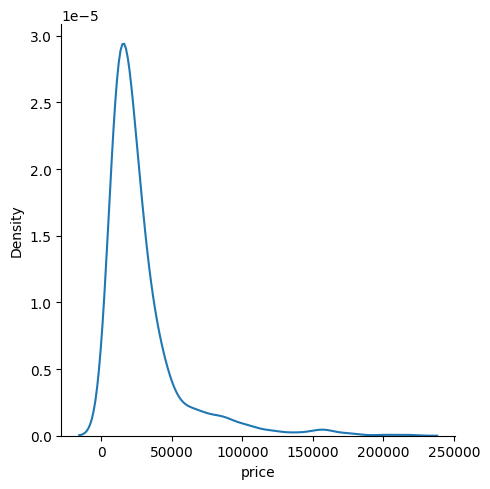

In [48]:
# Checking distrubution of data
sns.displot(data=df1, x = df1['price'], kind = 'kde')

In [49]:
# Checking Skewness
df1['price'].skew()

np.float64(2.93046257284421)

<Axes: xlabel='price'>

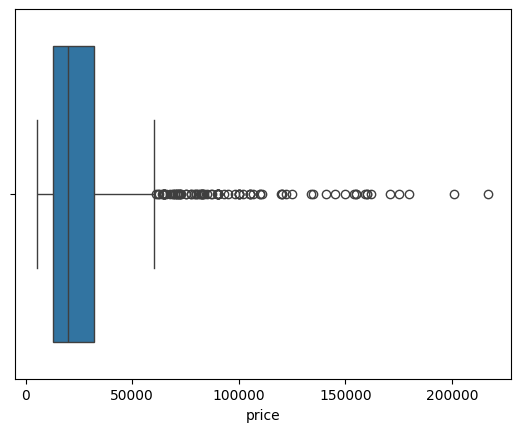

In [50]:
# Checking for an outliers
sns.boxplot(data = df1, x = df1['price'])

In [51]:
# Studying outliers
df1[df1['price'] > 200000]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
263,Samsung Galaxy Z Fold 7,216999,Android,Samsung,Snapdragon,Octa,4.47,16,1056.0,4400.0,25.0,8.0,120.0,True,NaN,0,True
839,Samsung Galaxy Z Fold 6,200999,NaN,Samsung,Snapdragon,Octa,3.39,12,1056.0,4400.0,25.0,7.6,120.0,True,NaN,0,True


In [52]:
# checking for null values
df1['price'].isnull().sum()

np.int64(0)

# ***2. gigahertz :-***

***Conclusion:-***
- again this column is also right skewed and skewness value is 1.24
- this column contains null values
- it also contains outliers but after studying those outliers, i understand that we cannot treat them as an outliers, cause all an outliers values are obtain for only those brands which have high price for their phones.
- and the price range of those brands phones lies between 50000 rs to 1,75000 rs.

In [53]:
# Checking Discriptives Statatics
df1['gigahertz'].describe()

count    832.000000
mean       2.635793
std        0.549574
min        1.600000
25%        2.400000
50%        2.500000
75%        2.850000
max        4.470000
Name: gigahertz, dtype: float64

<Axes: xlabel='gigahertz', ylabel='Density'>

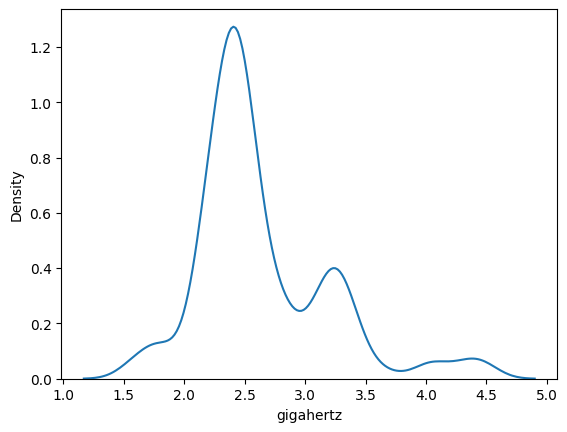

In [54]:
# Checking Distrubution
sns.kdeplot(data=df1, x=df1['gigahertz'])

In [55]:
# Checking Skewness
df1['gigahertz'].skew()

np.float64(1.2478164239548981)

<Axes: xlabel='gigahertz'>

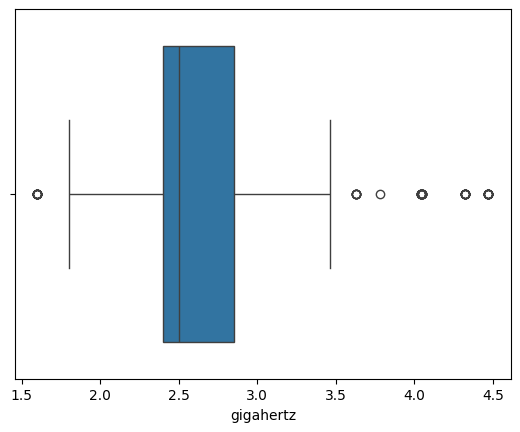

In [56]:
# Checking for outliers
sns.boxplot(data = df1, x = df1['gigahertz'])

In [57]:
# Checking for null values
df1['gigahertz'].isnull().sum()

np.int64(102)

In [58]:
# Studying outliers
df1[df1['gigahertz'] > 3.5].head()

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
31,Samsung Galaxy S25 Ultra,106400,Android,Samsung,Snapdragon,Octa,4.47,12,256.0,5000.0,45.0,6.90,120.0,True,12.0,1,False
51,Apple iPhone 16,72499,iOS,Apple,Bionic,Hexa,4.04,8,128.0,3561.0,NaN,6.10,NaN,True,12.0,2,False
58,OnePlus 13s,54998,Android,OnePlus,Snapdragon,Octa,4.32,12,256.0,5850.0,80.0,6.32,120.0,True,32.0,2,False
59,Samsung Galaxy S25,71090,NaN,Samsung,Snapdragon,Octa,4.47,12,256.0,4000.0,25.0,6.20,120.0,True,12.0,3,False
84,iQOO 13,54998,NaN,iQOO,Snapdragon,Octa,4.32,12,256.0,6000.0,120.0,6.82,144.0,True,32.0,3,False


# ***3. RAM***

***conclusion :-***

- this column is highly right skewed and skewness value is 21.65
- again this column does not contains null values
- it consists an outliers. after studying an outliers realizes that removing them is super necessary, because they are affecting on distrubution of this column.

In [59]:
# checking descriptive statatics
df1['RAM'].describe()

count    934.000000
mean       9.033191
std       19.298245
min        2.000000
25%        6.000000
50%        8.000000
75%        8.000000
max      512.000000
Name: RAM, dtype: float64

<Axes: ylabel='Density'>

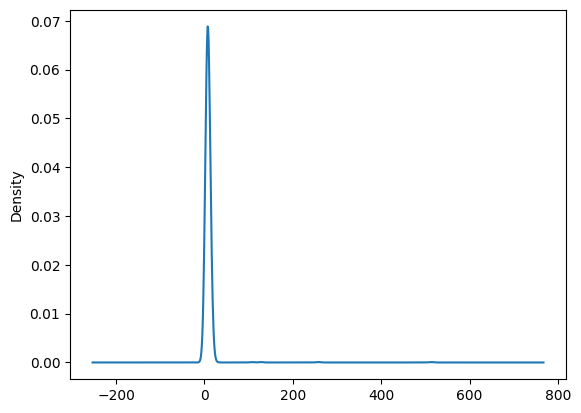

In [60]:
# Checking Distrubution
df1['RAM'].plot(kind='kde')

In [61]:
# Checking Skewness value
df1['RAM'].skew()

np.float64(21.657621149415874)

<Axes: xlabel='RAM'>

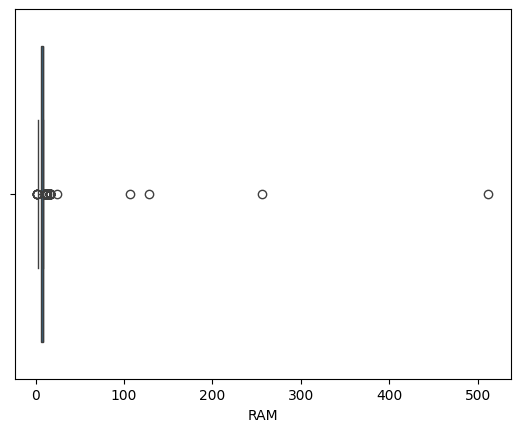

In [62]:
# Checking for outliers
sns.boxplot(data = df1,x = df1['RAM'])

In [63]:
# Studying outliers
df1[df1['RAM'] > 100]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
243,Apple iPhone 16 Plus,81900,iOS,Apple,Bionic,Hexa,4.04,128,NaN,4674.0,NaN,6.7,NaN,True,12.0,2,False
480,Apple iPhone 16 Plus,92900,iOS,Apple,Bionic,Hexa,4.04,256,NaN,4674.0,NaN,6.7,NaN,True,12.0,2,False
687,Apple iPhone 16 Plus,109999,iOS,Apple,Bionic,Hexa,4.04,512,NaN,4674.0,NaN,6.7,NaN,True,12.0,2,False
831,HMD Barbie Flip,7999,NaN,HMD,others,NaN,NaN,107,1056.0,NaN,NaN,0.0,NaN,False,NaN,0,True


In [64]:
# Checking for null values
df1['RAM'].isnull().sum()

np.int64(0)

# ***4. ROM :-***

***conclusion :-***
- the column is right skewed and skewness value is 2.97
- it consists null values
- it also consits an outliers and need to remove them


In [65]:
# Checking Descriptive statatics
df1['ROM'].describe()

count     931.000000
mean      206.556391
std       147.557883
min        16.000000
25%       128.000000
50%       128.000000
75%       256.000000
max      1056.000000
Name: ROM, dtype: float64

<Axes: xlabel='ROM', ylabel='Density'>

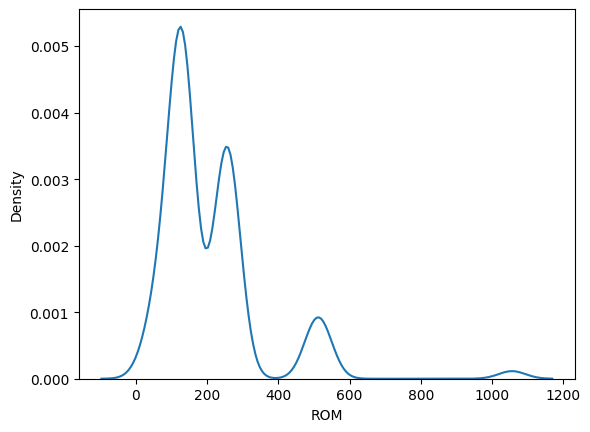

In [66]:
# Checking Distrubution
sns.kdeplot(data=df1,x=df1['ROM'])

In [67]:
# Checking Skewness
df1['ROM'].skew()

np.float64(2.670573387154321)

<Axes: xlabel='ROM'>

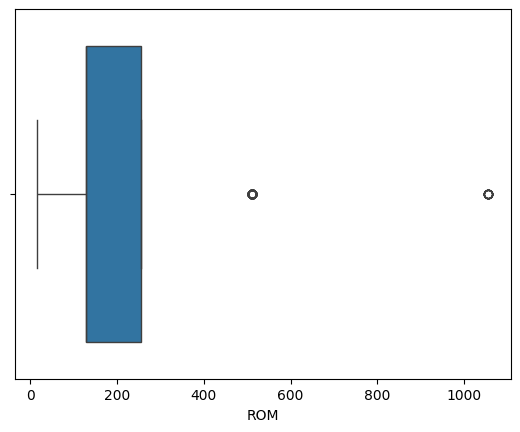

In [68]:
# Checking for outliers
sns.boxplot(data = df1, x =df1['ROM'])

In [69]:

# Studying outliers
df1[df1['ROM'] >1000]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
231,OnePlus 13,84999,Android,OnePlus,Snapdragon,Octa,4.32,24,1056.0,6000.0,100.0,6.82,120.0,True,32.0,3,False
263,Samsung Galaxy Z Fold 7,216999,Android,Samsung,Snapdragon,Octa,4.47,16,1056.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
353,Apple iPhone 16 Pro Max,170900,iOS,Apple,Bionic,Hexa,4.05,8,1056.0,4685.0,NaN,6.90,120.0,True,12.0,3,False
376,Samsung Galaxy S25 Ultra,153999,Android,Samsung,Snapdragon,Octa,4.47,12,1056.0,5000.0,45.0,6.90,120.0,True,12.0,1,False
490,Samsung Galaxy S24 Ultra,159999,Android,Samsung,Snapdragon,Octa,3.30,12,1056.0,5000.0,45.0,6.80,120.0,True,12.0,1,False
629,OnePlus Open Apex Edition,149998,NaN,OnePlus,Snapdragon,Octa,3.20,16,1056.0,4805.0,67.0,7.82,120.0,True,NaN,0,False
780,Apple iPhone 13 Pro Max,179900,iOS,Apple,Bionic,Hexa,3.22,6,1056.0,4352.0,NaN,6.70,120.0,True,12.0,3,False
820,Apple iPhone 16 Pro,161900,iOS,Apple,Bionic,Hexa,4.05,8,1056.0,3582.0,NaN,6.30,120.0,True,12.0,3,False
831,HMD Barbie Flip,7999,NaN,HMD,others,NaN,NaN,107,1056.0,NaN,NaN,0.00,NaN,False,NaN,0,True
839,Samsung Galaxy Z Fold 6,200999,NaN,Samsung,Snapdragon,Octa,3.39,12,1056.0,4400.0,25.0,7.60,120.0,True,NaN,0,True


In [70]:
# Checking for null values
df1['ROM'].isnull().sum()

np.int64(3)

# ***5. Battery_in_mah :-***

***conclusion :-***
- this column is exactly looks like normal distrubution
- consists null values
- it also consists outliers but we cannot treat them as outliers
- the values less than 4000 are mainly for those brands such as an apple and samsung whrere the price of this brands phones is high
- and the values are greater than 6000 are for other brands whose price range is between 20000rs to 50000 rs.
-  Such as from my observation the brands having high price are also having less battery capacity and brands having low price range are aslo having high battery capacity
- So this column is inversionally proportional to price column


In [71]:
# Checking Discriptive statatics
df1['battery_in_mAh'].describe()

count     933.000000
mean     5203.891747
std       732.156954
min      1170.000000
25%      5000.000000
50%      5000.000000
75%      5500.000000
max      7550.000000
Name: battery_in_mAh, dtype: float64

<Axes: xlabel='battery_in_mAh', ylabel='Density'>

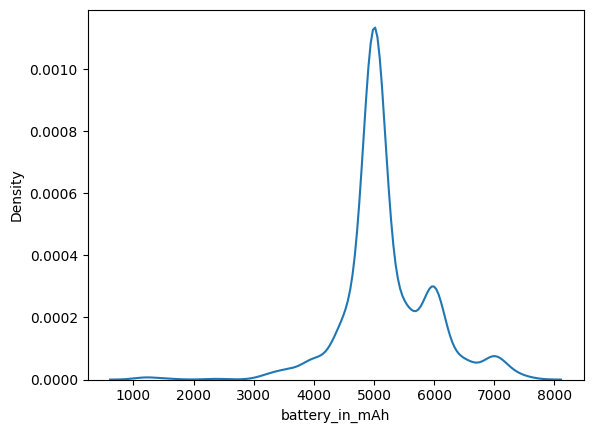

In [72]:
# checking distrubution
sns.kdeplot(data=df1, x=df1['battery_in_mAh'])

In [73]:
# Checking Skewness
df1['battery_in_mAh'].skew()

np.float64(-0.14132634104700625)

<Axes: xlabel='battery_in_mAh'>

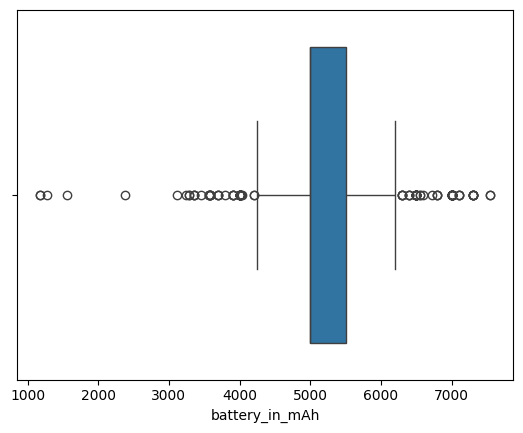

In [74]:
# Checking for outliers
sns.boxplot(data=df1,x=df1['battery_in_mAh'])

In [75]:
# checking for null values
df1['battery_in_mAh'].isnull().sum()

np.int64(1)

# ***6. Charging_support_in watt :-***

***conclusion :-***
- the distrubution of this column is closed to normal distrubution with 0.71 skewness value.
- it consists null values
- it also consists an outliers need to remove them

In [76]:
# Checking Descriptive statatics
df1['charging_support_in_watt'].describe()

count    877.000000
mean      48.877993
std       29.878788
min        5.000000
25%       25.000000
50%       44.000000
75%       70.000000
max      150.000000
Name: charging_support_in_watt, dtype: float64

<Axes: xlabel='charging_support_in_watt', ylabel='Density'>

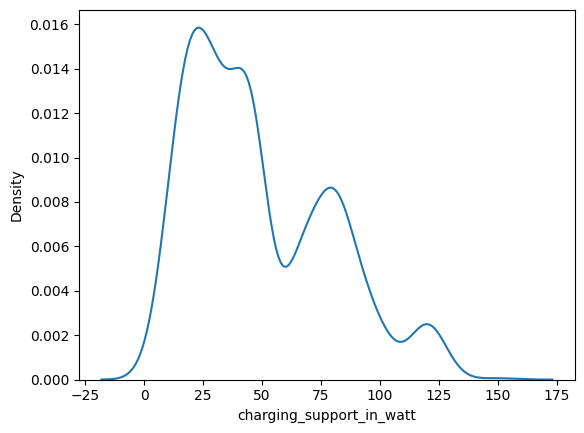

In [77]:
# Checking distrubution
sns.kdeplot(data = df1, x =df1['charging_support_in_watt'])

In [78]:
# Checking Skewness
df1['charging_support_in_watt'].skew()

np.float64(0.7593146708479249)

In [79]:
# Checking null values
df1['charging_support_in_watt'].isnull().sum()

np.int64(57)

<Axes: xlabel='charging_support_in_watt'>

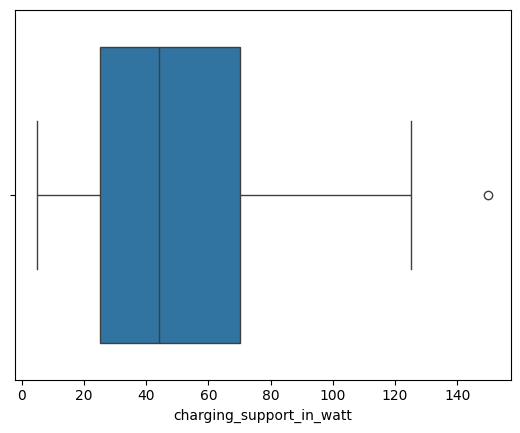

In [80]:
# checking outliers
sns.boxplot(data=df1,x=df1['charging_support_in_watt'])

In [81]:
# studying outliers
df1[df1['charging_support_in_watt'] > 140]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
45,Realme GT Neo 3,17000,NaN,Realme,Dimensity,Octa,2.85,12,256.0,4500.0,150.0,6.7,120.0,True,16.0,3,False


# ***7. Size_in_inch :-***

***conclusion :-***
- the distrubution in totally left skew or negative skewed with skewness value -11.41
- it does not consists null values
- it consits outliers but the values are less than 5 are only consider as outliers
- and again the values are greater than 7 are generally available for folded phones. so we cannot consider them as an outliers


In [82]:
# Checking dicsriptive statatics
df1['size_in_inch'].describe()

count    934.000000
mean       6.651842
std        0.435471
min        0.000000
25%        6.600000
50%        6.700000
75%        6.770000
max        8.030000
Name: size_in_inch, dtype: float64

<Axes: xlabel='size_in_inch', ylabel='Density'>

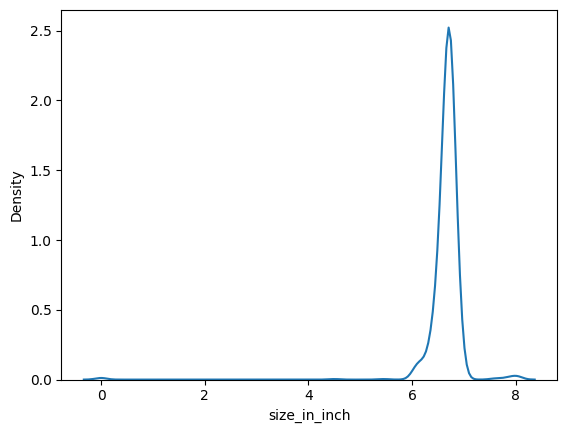

In [83]:
# Checking distrubution
sns.kdeplot(data=df1, x = df1['size_in_inch'])

In [84]:
# Checking Skewness
df1['size_in_inch'].skew()

np.float64(-11.412097470322335)

In [85]:
# Checking null values
df1['size_in_inch'].isnull().sum()

np.int64(0)

<Axes: xlabel='size_in_inch'>

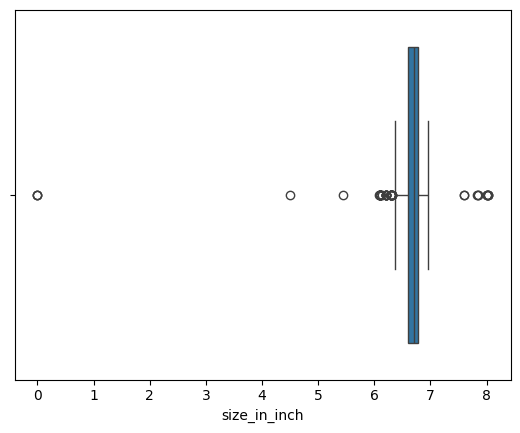

In [86]:
# Checking Outliers
sns.boxplot(data=df1,x=df1['size_in_inch'])

In [87]:
# Studying outliers
df1[df1['size_in_inch']<5]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
507,Apple iPhone 12,44999,NaN,Apple,Bionic,Hexa,3.10,4,64.0,1170.0,NaN,0.0,NaN,True,NaN,0,False
552,BlackBerry Passport,25999,NaN,BlackBerry,Snapdragon,Quad,2.26,3,32.0,3450.0,NaN,4.5,NaN,False,2.0,1,False
607,Apple iPhone 12,43999,NaN,Apple,Bionic,Hexa,3.10,4,128.0,1170.0,NaN,0.0,NaN,True,NaN,0,False
831,HMD Barbie Flip,7999,NaN,HMD,others,NaN,NaN,107,1056.0,NaN,NaN,0.0,NaN,False,NaN,0,True


In [88]:
df1[df1['size_in_inch']>7]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
198,Samsung Galaxy Z Fold 7,158999,Android,Samsung,Snapdragon,Octa,4.47,12,256.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
263,Samsung Galaxy Z Fold 7,216999,Android,Samsung,Snapdragon,Octa,4.47,16,1056.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
378,Vivo X Fold 5,144990,Android,Vivo,Snapdragon,Octa,3.30,16,512.0,6000.0,80.0,8.03,120.0,True,NaN,0,True
457,Samsung Galaxy Z Fold 6,119889,Android,Samsung,Snapdragon,Octa,3.39,12,256.0,4400.0,25.0,7.60,120.0,True,NaN,0,True
473,Samsung Galaxy Z Fold 7,174999,Android,Samsung,Snapdragon,Octa,4.47,12,512.0,4400.0,25.0,8.00,120.0,True,NaN,0,True
494,Tecno Phantom V Fold 2,89999,Android,Tecno,Dimensity,Octa,3.20,12,512.0,5750.0,70.0,7.85,120.0,True,NaN,0,True
534,Vivo X Fold 3 Pro,159999,NaN,Vivo,Snapdragon,Octa,3.30,16,512.0,5700.0,100.0,8.03,120.0,True,NaN,0,True
571,Google Pixel 9 Pro Fold,134999,Android,Google,Tensor,Octa,3.10,16,256.0,4650.0,NaN,8.03,120.0,True,NaN,0,True
629,OnePlus Open Apex Edition,149998,NaN,OnePlus,Snapdragon,Octa,3.20,16,1056.0,4805.0,67.0,7.82,120.0,True,NaN,0,False
839,Samsung Galaxy Z Fold 6,200999,NaN,Samsung,Snapdragon,Octa,3.39,12,1056.0,4400.0,25.0,7.60,120.0,True,NaN,0,True


# ***8. Refresh_rate :-***
***conclusion :-***
- the distrubution seems to normal with skewness value -0.51
- it consists null values
- it also consinsts outliers. need to remove them



In [89]:
# Checking Descriptive statatics
df1['refresh_rate'].describe()

count    842.000000
mean     116.091449
std       14.157596
min       90.000000
25%      120.000000
50%      120.000000
75%      120.000000
max      165.000000
Name: refresh_rate, dtype: float64

<Axes: xlabel='refresh_rate', ylabel='Density'>

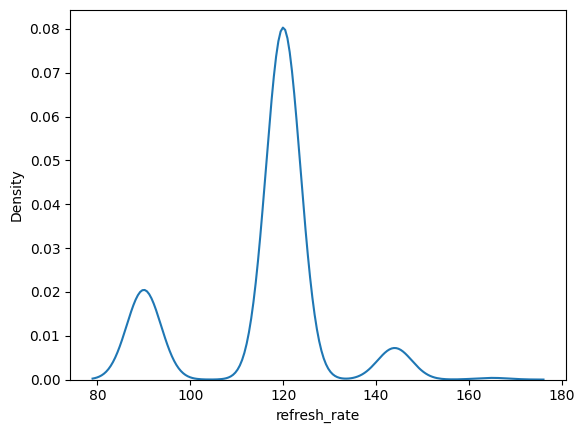

In [90]:
# Checking distrubution
sns.kdeplot(data = df1, x =df1['refresh_rate'])

In [91]:
# Checking Skewness
df1['refresh_rate'].skew()

np.float64(-0.5118493635628285)

In [92]:
# Checking null values
df1['refresh_rate'].isnull().sum()

np.int64(92)

<Axes: xlabel='refresh_rate'>

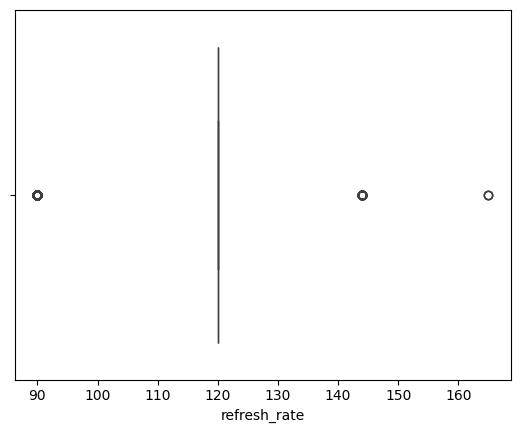

In [93]:
# Checking outliers
sns.boxplot(data=df1,x=df1['refresh_rate'])

In [94]:
# Studying outliers
df1[df1['refresh_rate']> 145]

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
400,Motorola Razr 60 Ultra,89998,NaN,Motorola,Snapdragon,Octa,4.32,16,512.0,4700.0,68.0,6.96,165.0,True,NaN,0,False
739,Motorola Razr 50 Ultra,89999,NaN,Motorola,Snapdragon,Octa,NaN,12,512.0,4000.0,45.0,6.90,165.0,True,NaN,0,False
897,Motorola Razr 40 Ultra,44249,NaN,Motorola,Snapdragon,Octa,3.20,8,256.0,3800.0,30.0,6.90,165.0,True,NaN,0,False


# ***9. front_camera_in_megapixel :-***

***conclusion :-***
- the distrubution of this column is little right skewed with skewness value 1.51
- it consists null values
- it does not consists an outliers

In [95]:
# Checking Discriptive statatics
df1['front_camera_in_megapixel'].describe()

count    901.000000
mean      19.471698
std       13.783183
min        2.000000
25%        8.000000
50%       16.000000
75%       32.000000
max       60.000000
Name: front_camera_in_megapixel, dtype: float64

<Axes: xlabel='front_camera_in_megapixel', ylabel='Density'>

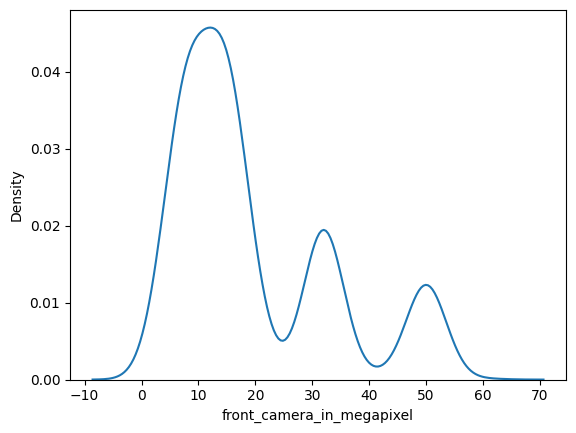

In [96]:
# Checking Disrubution
sns.kdeplot(data=df1,x=df1['front_camera_in_megapixel'])

In [97]:
# Checking skew
df1['front_camera_in_megapixel'].skew()

np.float64(1.1102792939816686)

In [98]:
# Checking Null values
df1['front_camera_in_megapixel'].isnull().sum()

np.int64(33)

<Axes: xlabel='front_camera_in_megapixel'>

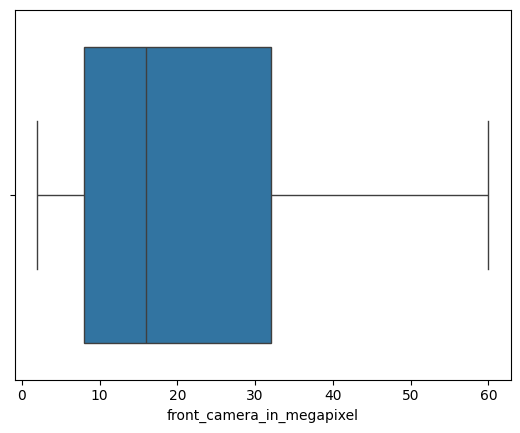

In [99]:
# Checing outliers
sns.boxplot(data=df1,x=df1['front_camera_in_megapixel'])

# ***Catagorical cloumns :-***
# ***1. brand***

***conclusion :-***
- there are 32 kinds of brands are avilble in market
- and top 5 brands are :- Samsung, vivo, xiomi, realme, oppo

In [100]:
# Checking Discriptive Statatics
df1['brand'].value_counts().reset_index()

,brand,count
0,Samsung,147
1,Realme,131
2,Vivo,123
3,Xiaomi,77
4,OPPO,71
5,Motorola,56
6,POCO,45
7,iQOO,41
8,Infinix,38
9,OnePlus,35


<Axes: ylabel='count'>

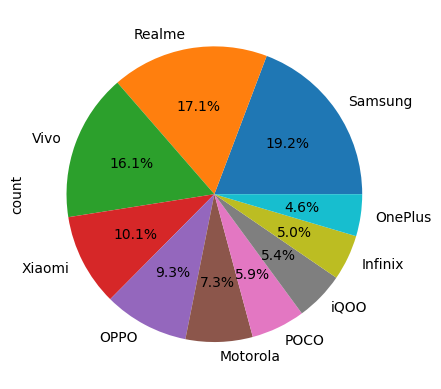

In [101]:
# Fetching percentage of available phones in market of each of top 10 brands

df1['brand'].value_counts().head(10).plot(kind='pie',autopct= '%0.1f%%')


# ***2. Mobile_processore :-***

***conclusion :-***
- the dimensty and snapdragon are mobile processors have capture 76% of total market.
- the null values are not presented in this column

In [102]:
df1['mobile_processor'].value_counts()

mobile_processor
Dimensity     388
Snapdragon    324
Exynos         58
Helio          57
Unisoc         47
Bionic         30
Tensor         18
Tiger           7
others          5
Name: count, dtype: int64

<Axes: ylabel='count'>

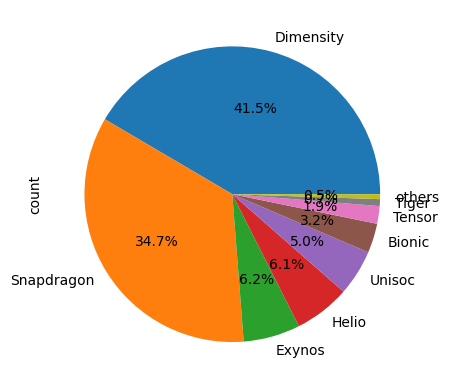

In [103]:
# Getting percentage of mobile processores
df1['mobile_processor'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [104]:
# Checking for null values
df1['mobile_processor'].isnull().sum()

np.int64(0)

# ***3. core :-***

***conclusion :-***
- the measure phones are avialble in market with octa core with 99%.
- the octa cores are for android phones
- the hexa cores are for ios phones

In [105]:
# Descriptive statatics
df1['core'].value_counts()

core
Octa      883
Hexa       31
Deca        9
Nine        5
Quad        2
others      1
Name: count, dtype: int64

<Axes: ylabel='count'>

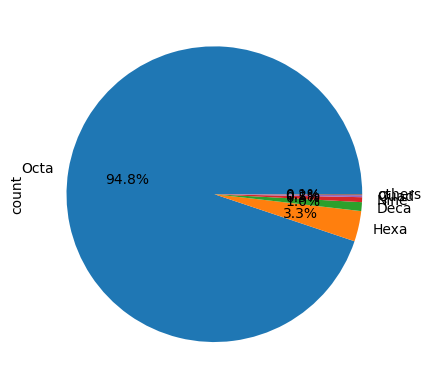

In [106]:
# Checking percentage
df1['core'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# ***4. has_5G :-***

***conclusion :-***
- no null values are presented in this column
- the most  phones are 5G phones

In [107]:
# getting value_counts
df1['has_5G'].value_counts()

has_5G
True     794
False    140
Name: count, dtype: int64

<Axes: ylabel='count'>

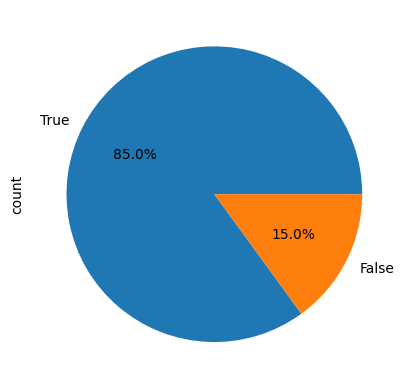

In [108]:
# Getting percentage of 5g and non 5g phones
df1['has_5G'].value_counts().plot(kind='pie',autopct= '%0.1f%%')

In [109]:
# Checking for null values
df1['has_5G'].isnull().sum()

np.int64(0)

# ***5. rear_cameras :-***

***conclusion :-***
- null values are present in this column
-

In [110]:
# Getting value counts
df1['rear_camera'].value_counts()

rear_camera
2    383
3    347
1    172
0     32
Name: count, dtype: int64

<Axes: ylabel='count'>

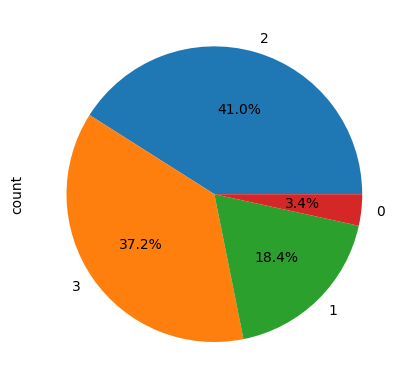

In [111]:
# checking percentage
df1['rear_camera'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [112]:
# checking null values
df1['rear_camera'].isnull().sum()

np.int64(0)

# ***6. os :-***

***conclusion:-***
- null values are present in this column


In [113]:
# Checking Discriptive statatics
df1['os'].value_counts()

os
Android    636
iOS         29
Name: count, dtype: int64

<Axes: ylabel='count'>

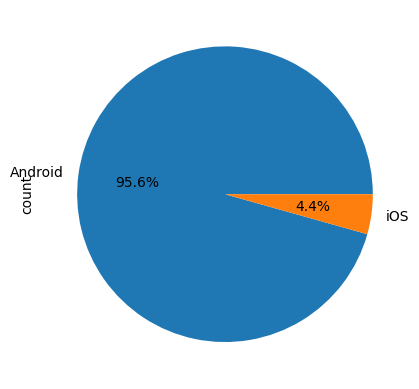

In [114]:
df1['os'].value_counts().plot(kind='pie',autopct = '%0.1f%%')

In [115]:
# Checking for null values
df1['os'].isnull().sum()

np.int64(269)

In [116]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   phone_name                 934 non-null    object 
 1   price                      934 non-null    int64  
 2   os                         665 non-null    object 
 3   brand                      934 non-null    object 
 4   mobile_processor           934 non-null    object 
 5   core                       931 non-null    object 
 6   gigahertz                  832 non-null    float64
 7   RAM                        934 non-null    int64  
 8   ROM                        931 non-null    float64
 9   battery_in_mAh             933 non-null    float64
 10  charging_support_in_watt   877 non-null    float64
 11  size_in_inch               934 non-null    float64
 12  refresh_rate               842 non-null    float64
 13  has_5G                     934 non-null    bool   

# ***Bivariate Analysis :-***

***column type ---- Numerical vs Numericals :-***

# ***1. Price vs gigahertz :-***

***conclusion :-***
- there is a sort of liniear relation is obtain in this two columns
- the most of the smartphones are at lower price range, such as under 50000rs with 2.0 to 3.0 gegahertz speed.

<Axes: xlabel='price', ylabel='gigahertz'>

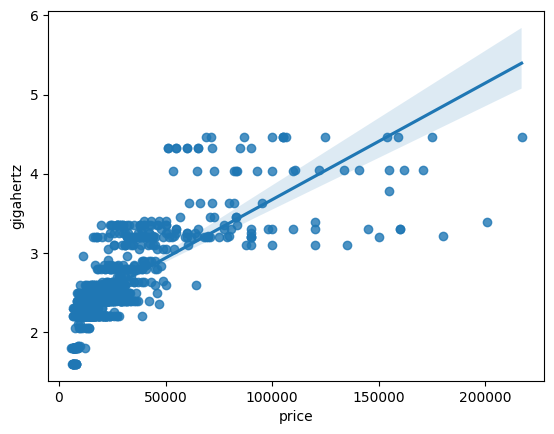

In [117]:
# looking for linier co-relation
sns.regplot(data = df1, x = 'price', y = 'gigahertz')

In [118]:
# Sepearing numerical and categorical columns for getting co-relation value
nums = df1.select_dtypes(include='number').columns
cats = df1.select_dtypes(include=['object','category']).columns

<Axes: xlabel='price', ylabel='gigahertz'>

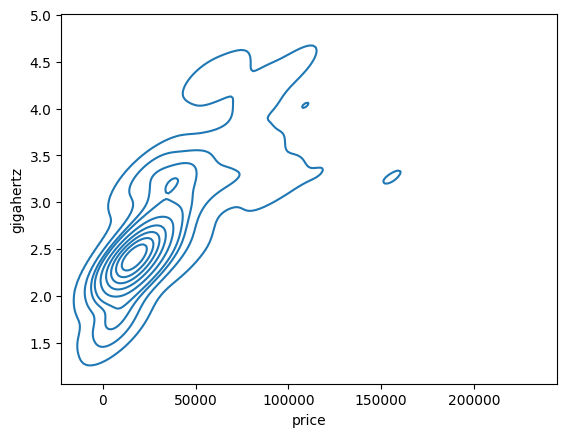

In [119]:
# getting distrubution of both columns
sns.kdeplot(data = df1, x='price',y='gigahertz')

# ***2. price vs RAM :-***

### ***conclusion :-***

- Ram column consists outliers


<Axes: xlabel='price', ylabel='RAM'>

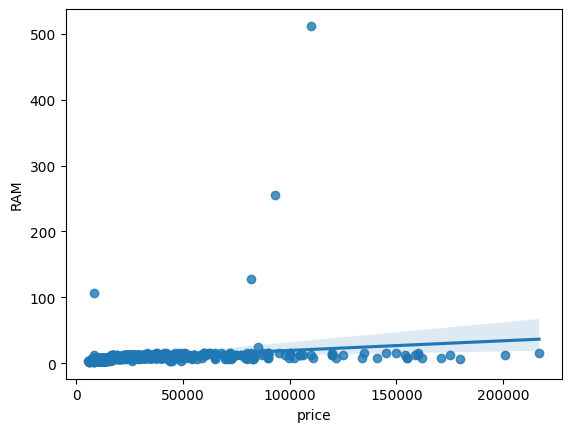

In [120]:
# plotting scatter plot
sns.regplot(data = df1, x='price', y='RAM')

<Axes: xlabel='price', ylabel='RAM'>

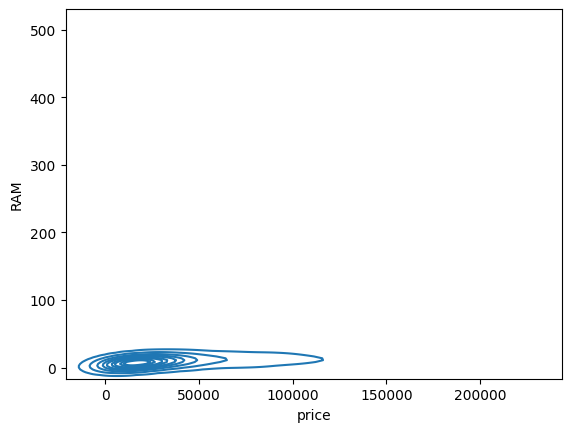

In [121]:
# plotting 2d kde plot
sns.kdeplot(data = df1, x='price', y='RAM')

# ***3. price vs ROM :-***

### ***conclusion :-***

- the most of the phones are under 50000 and the ROM is less than 400

<Axes: xlabel='price', ylabel='ROM'>

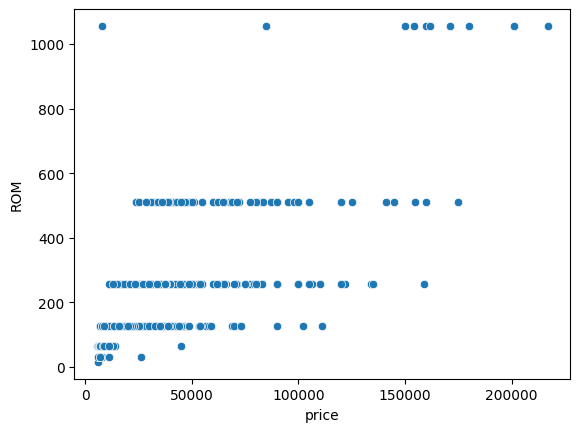

In [122]:
# Plotting scatter plot

sns.scatterplot(data = df1, x='price',y='ROM')

<Axes: xlabel='price', ylabel='ROM'>

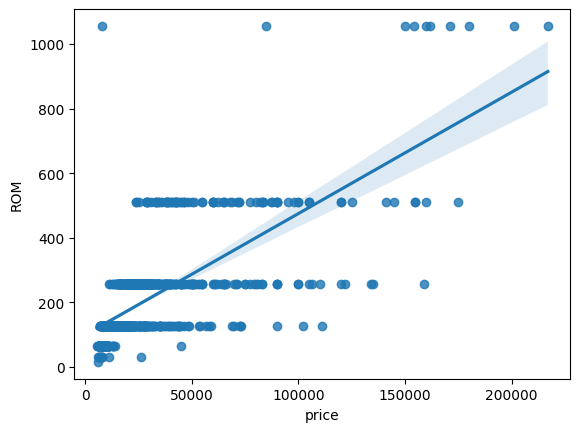

In [123]:
# Checking linier co-relation
sns.regplot(data = df1, x='price',y='ROM')

<Axes: xlabel='price', ylabel='ROM'>

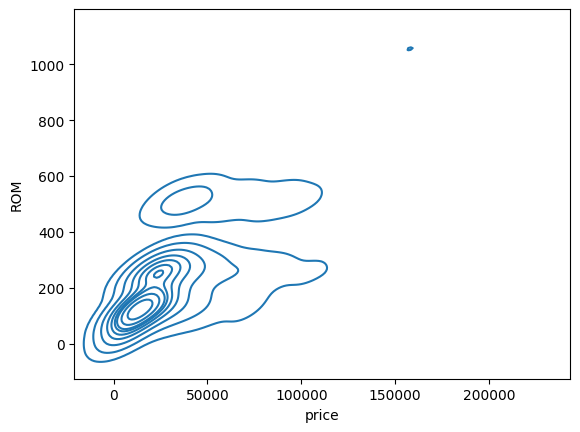

In [124]:
# plotting 2d kde plot

sns.kdeplot(data = df1, x='price',y='ROM')

# 4. Price vs battery_in_mAh

**conclusion:-**
- the most of the phones are lies under 50000 rs and most of the battery capacity lies in 4000 to 6000 mah

<Axes: xlabel='price', ylabel='battery_in_mAh'>

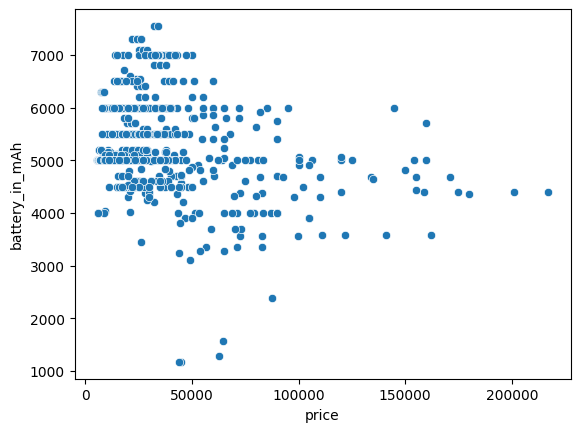

In [125]:
sns.scatterplot(data= df1, x ='price', y = 'battery_in_mAh')

<Axes: xlabel='price', ylabel='battery_in_mAh'>

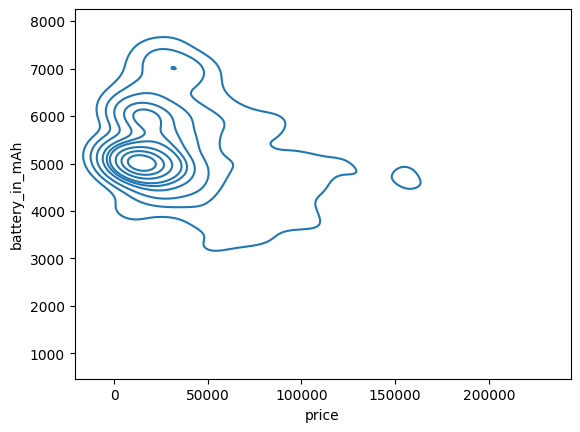

In [126]:
# plotting 2d Kde plot
sns.kdeplot(data=df1,x='price',y='battery_in_mAh')

# 5. price vs charging_support_in_watt
**conclusion :-**
- there is a sort of linier co-relation between this two columns. i mean  if price increases then the charging_support_in_watt is also increases
- most of the charging_support_in_watt values are lies in 20 to 75 for under 50000 rs of phones

<Axes: xlabel='price', ylabel='charging_support_in_watt'>

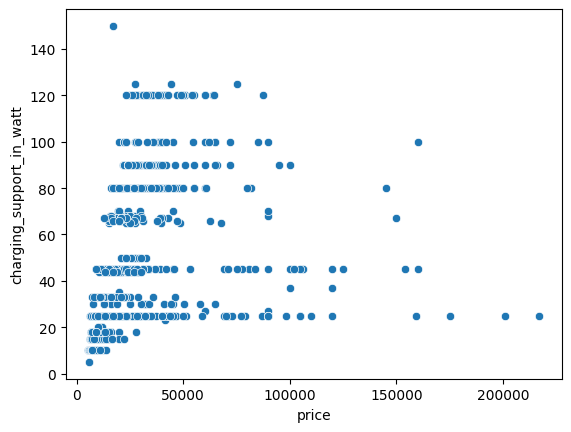

In [127]:
# plotting scatterplot
sns.scatterplot(data = df1, x= 'price', y='charging_support_in_watt')

<Axes: xlabel='price', ylabel='charging_support_in_watt'>

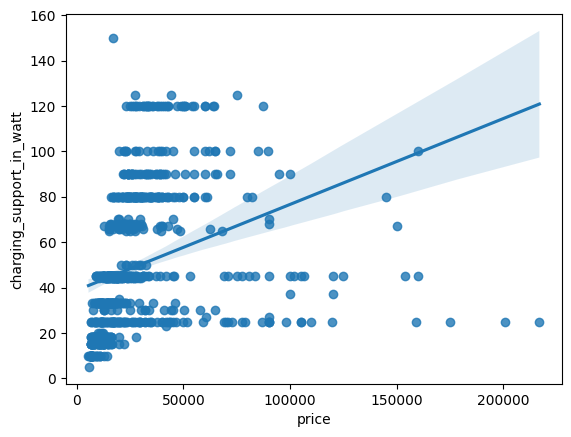

In [128]:
# Checking linier relation between this two columns
sns.regplot(data = df1, x= 'price', y='charging_support_in_watt')

<Axes: xlabel='price', ylabel='charging_support_in_watt'>

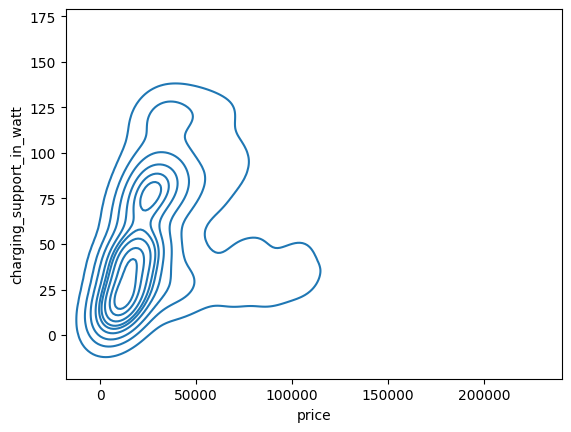

In [129]:
# plotting 2d kde plot
sns.kdeplot(data = df1, x='price',y='charging_support_in_watt')

# 6. price vs size_in_inch
**concluson:-**
- most of the phones having price under 50000 and size in inch is between 6 and 7
- and the phone which have high price is more than 50000 and the size is between 7 and 8


<Axes: xlabel='price', ylabel='size_in_inch'>

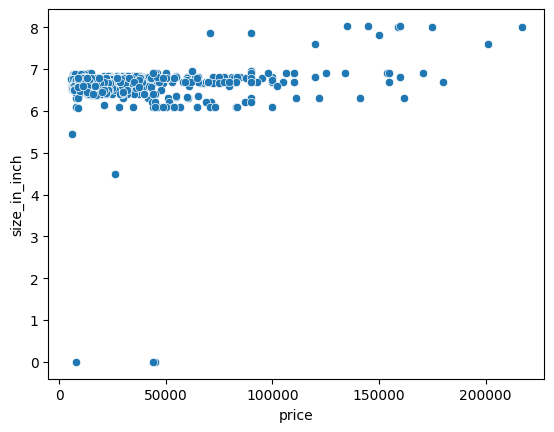

In [130]:
# plotting scatter plot
sns.scatterplot(data=df1,x='price',y='size_in_inch')

<Axes: xlabel='price', ylabel='size_in_inch'>

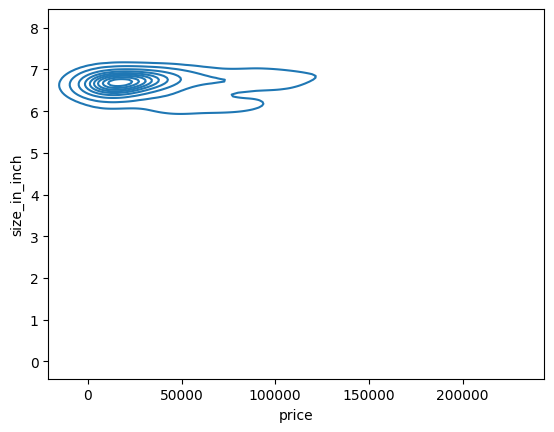

In [131]:
# plotting 2d kde plot
sns.kdeplot(data=df1,x='price',y='size_in_inch')

# 8. price vs refresh_rate
**conclusion:-**
- most of the phones having refresh rate between 80 to 140 and the price of those phones are lies in under 50000rs 

<Axes: xlabel='price', ylabel='refresh_rate'>

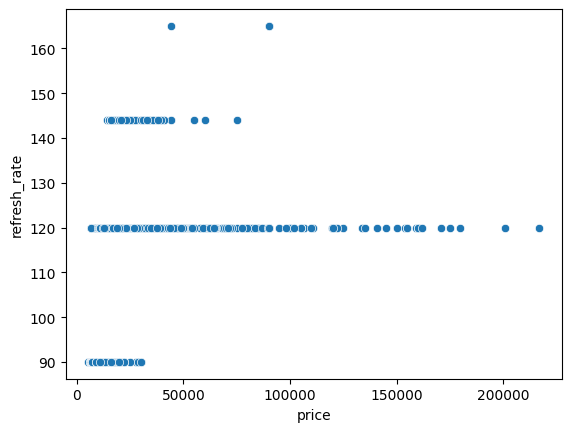

In [132]:
# plotting scatter plot
sns.scatterplot(data=df1,x='price',y='refresh_rate')

<Axes: xlabel='price', ylabel='refresh_rate'>

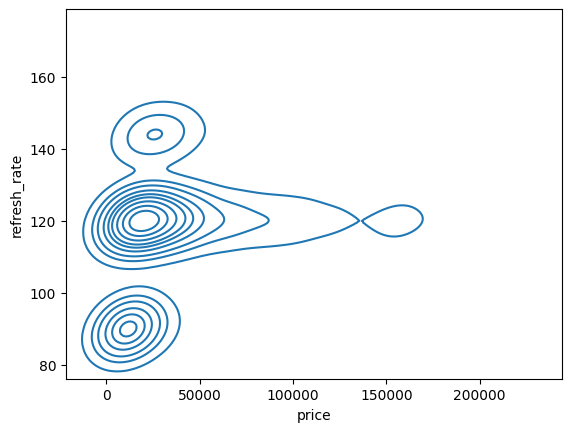

In [133]:
# plotting kde plot
sns.kdeplot(data=df1,x='price',y='refresh_rate')

# 9. price vs front_camera_in_megapixel
**conclusion:-**
- most of the phone having  camera in 8 to 30 megapixel and price is under 25000 rs

<Axes: xlabel='price', ylabel='front_camera_in_megapixel'>

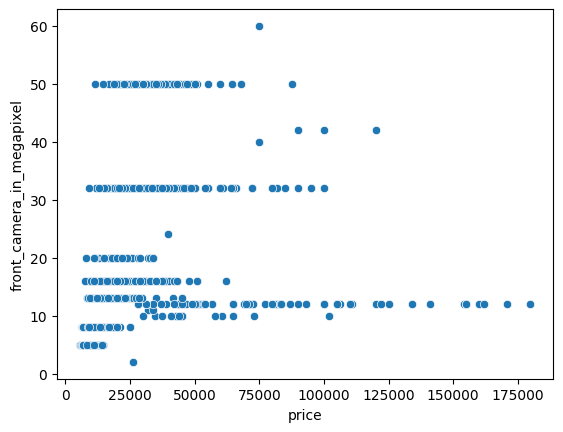

In [134]:
# plotting scatter plot
sns.scatterplot(data=df1,x='price',y='front_camera_in_megapixel')

<Axes: xlabel='price', ylabel='front_camera_in_megapixel'>

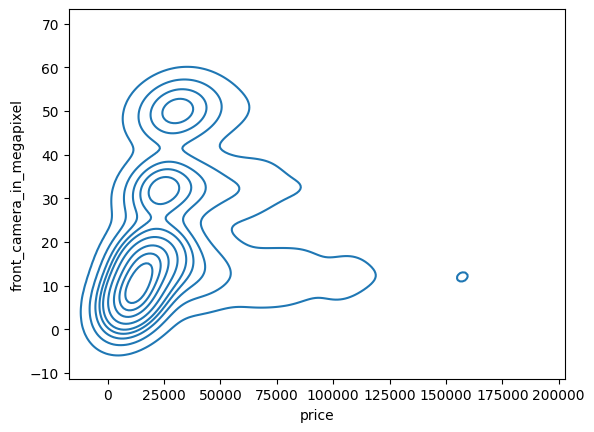

In [135]:
# plotting 2d kde plot
sns.kdeplot(data=df1,x='price',y='front_camera_in_megapixel')

# Column type ---- Numerical vs Categorical

# 1. price vs os
**conclusion:-**
- in general the price is directly proportional to operating system.
- again the average price of android phones is 20000 rs and average price of ios phones is near about 100000 rs.
- the android phones are cheap and ios phones are costly in price.
- again in android phones most phone are cheap but it also consists high costly phones.
- and in ios phones very less phone are cheap, but most of the phones are too costly

<Axes: xlabel='os', ylabel='price'>

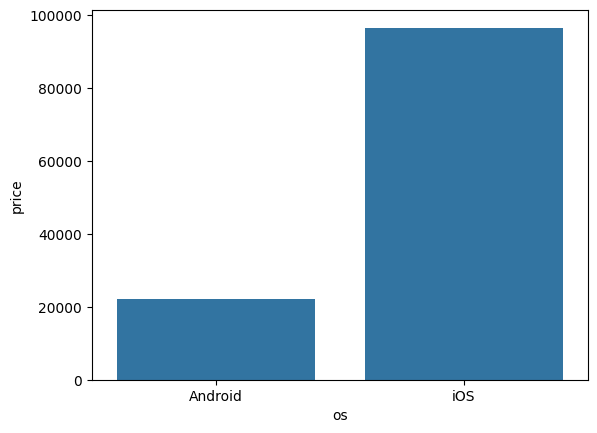

In [136]:
# plotting bar plot
sns.barplot(data=df1,x='os',y='price',errorbar=None)

<Axes: xlabel='os', ylabel='price'>

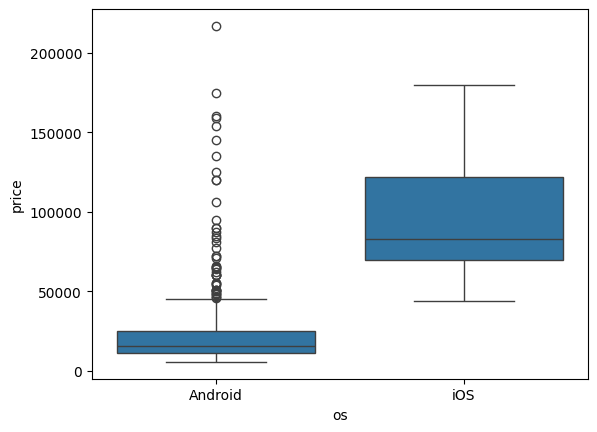

In [137]:
# plotting boxplot
sns.boxplot(data= df1, x= 'os',y ='price')

<Axes: xlabel='os', ylabel='price'>

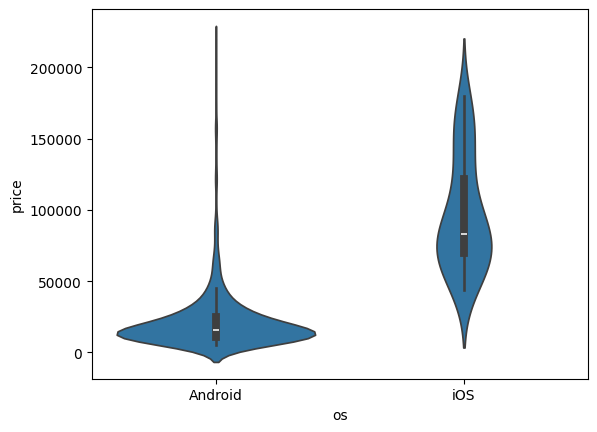

In [138]:
# plotting violin plot
sns.violinplot(data= df1, x= 'os',y ='price')

# 2. price vs brand
**conclusion:-**
- the apple is only brand having high as price compares to others.
- after apple the samsung,oneplus and google are top brands who have high price of their phones.

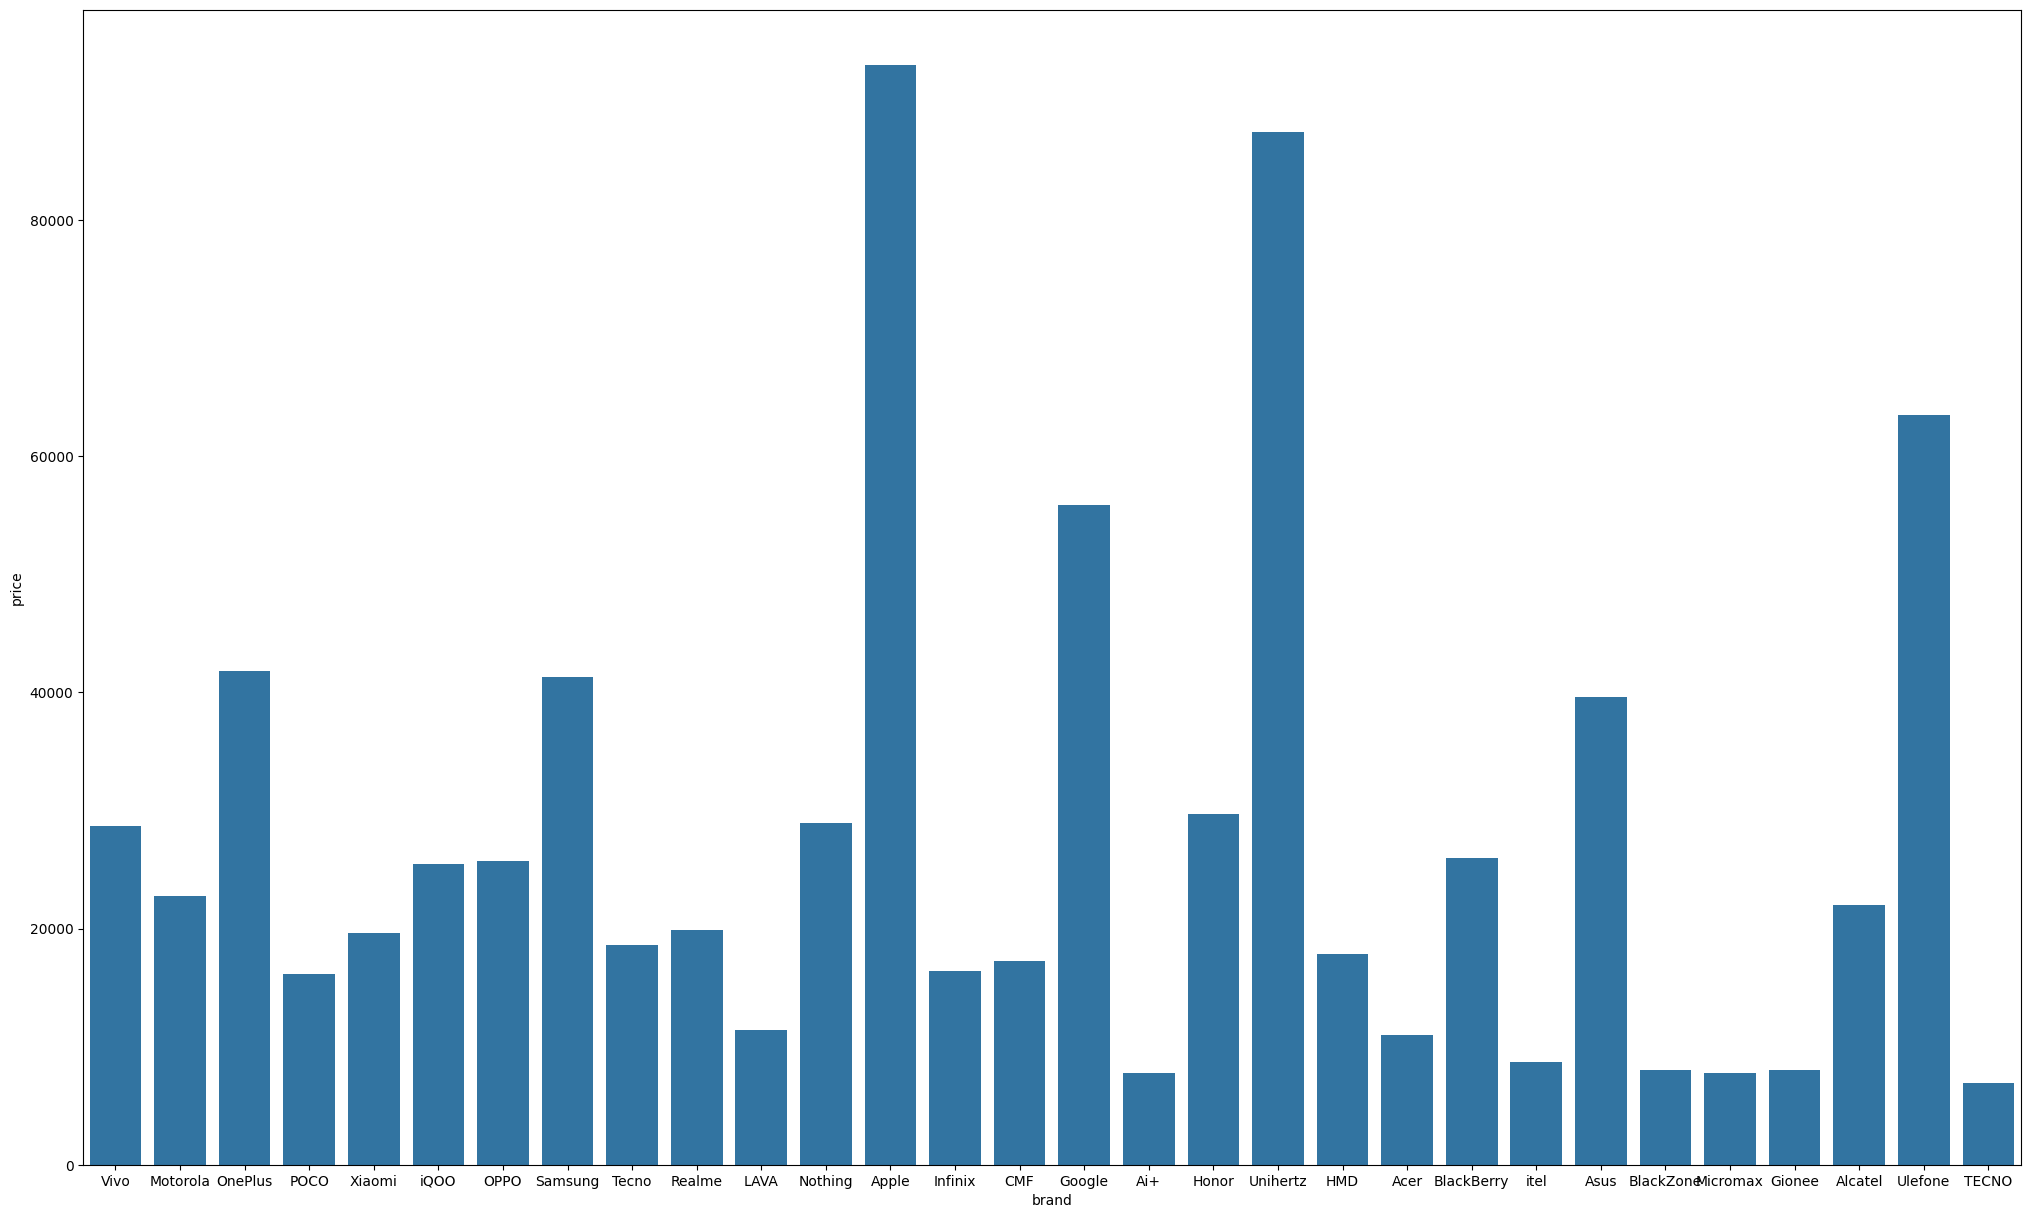

In [139]:
# plotting bar plot
plt.figure(figsize = (25,15))
sns.barplot(data=df1,x='brand',y='price',errorbar=None)
plt.show()

# 3. price vs mobile_processor
**conclusion:-**
- the mobile processor having highest price is bionic
- and after that snapdragon, tensor and Exynos

<Axes: xlabel='mobile_processor', ylabel='price'>

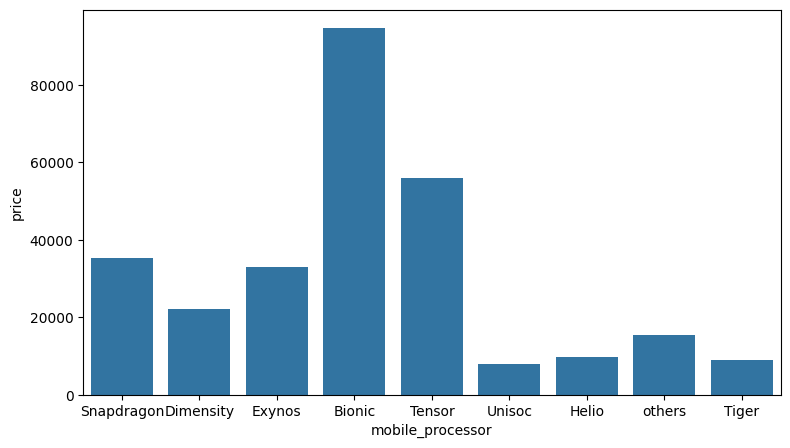

In [140]:
plt.figure(figsize=(9,5))
sns.barplot(data=df1,x='mobile_processor',y='price',errorbar=None)

# 4. price vs core
**conclusion:-**
- most costly cores are Hexa and after that deca

<Axes: xlabel='core', ylabel='price'>

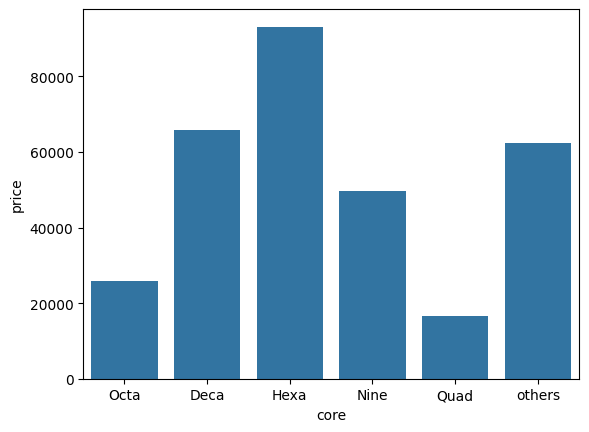

In [141]:
# plotting bar plot
sns.barplot(data= df1,x='core',y='price',errorbar=None)

# 5. price vs has_5G
**cocnlusion:-**
- the average price of 5g phones is near about 30000 rs and average price of non 5g phones is 10000 rs
- most of the phones are 5G phones but cost of some phones is much higher than average price

<Axes: xlabel='has_5G', ylabel='price'>

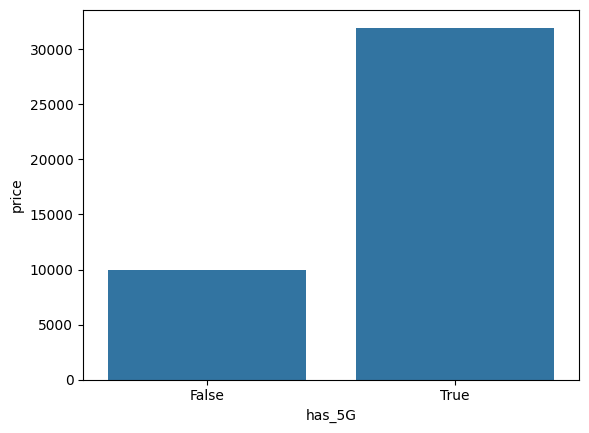

In [142]:
# plotting bar plot
sns.barplot(data=df1,x='has_5G',y='price',errorbar= None)

<Axes: xlabel='has_5G', ylabel='price'>

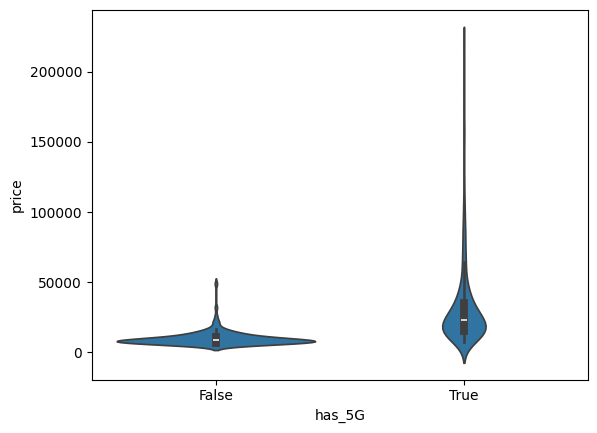

In [143]:
# plotting violin plot
sns.violinplot(data=df1,x='has_5G',y='price')

# 6. price vs is_folded
**cocclusion:-**
- the folded phones are high in price as compare to non-foldable phones
- the quatity of folded phones is less as compare to non-foldable phones.

<Axes: xlabel='is_folded', ylabel='price'>

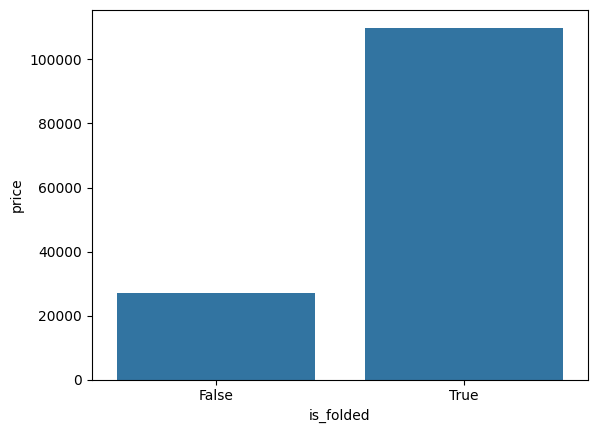

In [144]:
# plotting bar plot
sns.barplot(data=df1,x='is_folded',y='price',errorbar=None)

<Axes: xlabel='is_folded', ylabel='price'>

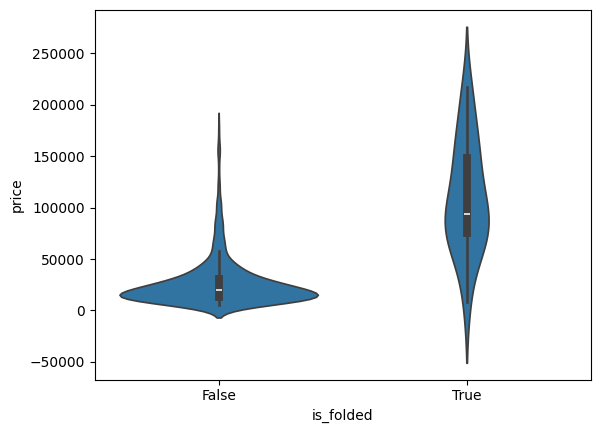

In [145]:
# plotting violinplot
sns.violinplot(data=df1,x='is_folded',y='price')

# 7. price vs rear_camera
**cocnlusion:-**
- most of the phones under 50000 having 2 or more cameras

<Axes: xlabel='price', ylabel='rear_camera'>

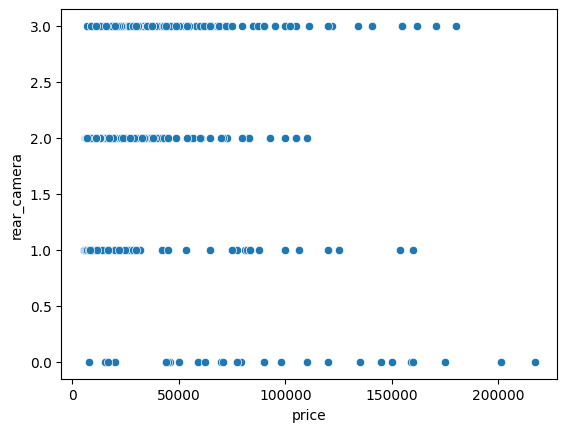

In [146]:
# plotting scatter plot
sns.scatterplot(data=df1,x='price',y='rear_camera')

<Axes: xlabel='price', ylabel='rear_camera'>

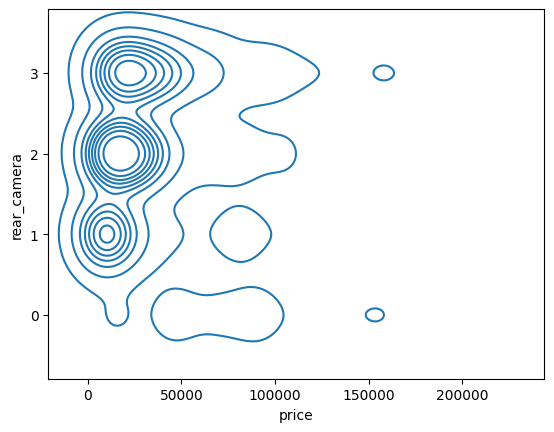

In [147]:
# plotting kde plot
sns.kdeplot(data=df1,x='price',y='rear_camera')

## Categorical vs Categorical columns

# os vs core
**conclusion:-**

- here 100 percent hexa core are in ios phones
- and 99.17 percent of octa core is in android phones

<Axes: xlabel='core', ylabel='os'>

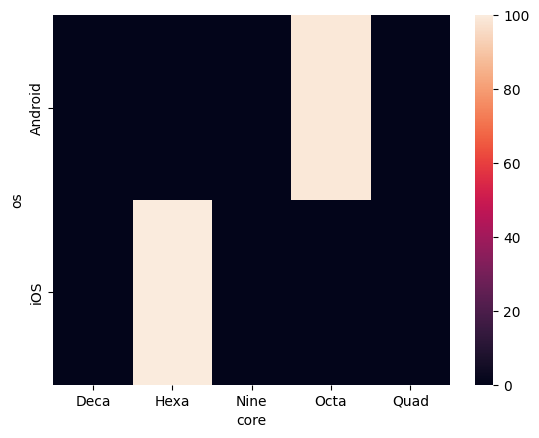

In [148]:
# using cross tables to fetch required information.
sns.heatmap(pd.crosstab(df1['os'],df1['core'],normalize='index')*100)

# os vs has_5G
**conclusion:-**
- 79 % android phones are 5g phones and 97% of ios phones are 5G phones

In [149]:
#  creating cross table or contaginious tables
pd.crosstab(df1['os'],df1['has_5G'],normalize='index')*100

has_5G,False,True
os,,
Android,21.069182,78.930818
iOS,3.448276,96.551724


<Axes: xlabel='has_5G', ylabel='os'>

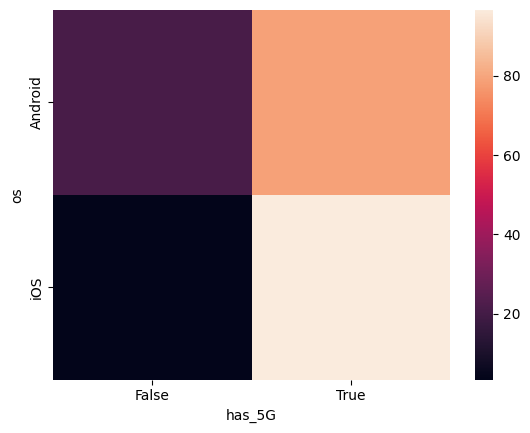

In [150]:
sns.heatmap(pd.crosstab(df1['os'],df1['has_5G'],normalize='index')*100)

# os vs is_folded
**conclusion:-**
- only 1.25% of phones are folded phones from android.
- 0.0% of phones are folded from ios

In [151]:
# making a contagenous table
pd.crosstab(df1['os'],df1['is_folded'],normalize='index')*100

is_folded,False,True
os,,
Android,98.742138,1.257862
iOS,100.000000,0.000000


<Axes: xlabel='is_folded', ylabel='os'>

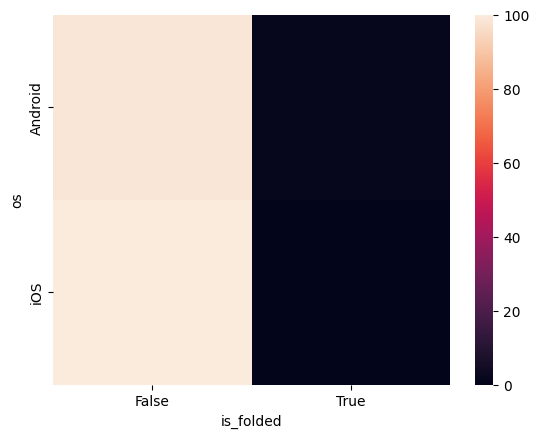

In [152]:
# Generating a heatmap
sns.heatmap(pd.crosstab(df1['os'],df1['is_folded'],normalize='index')*100)

# Multivariate Analysis
**Question:-**
1. compare the price with has_5G and brand.
- Most of brands have both 5G and non 5G phones. But the average price of 5G phones is greater than the average price of non 5g phone of same brands.
- from that we can easily conclude that generation is directly affects on price.

<Axes: xlabel='brand', ylabel='price'>

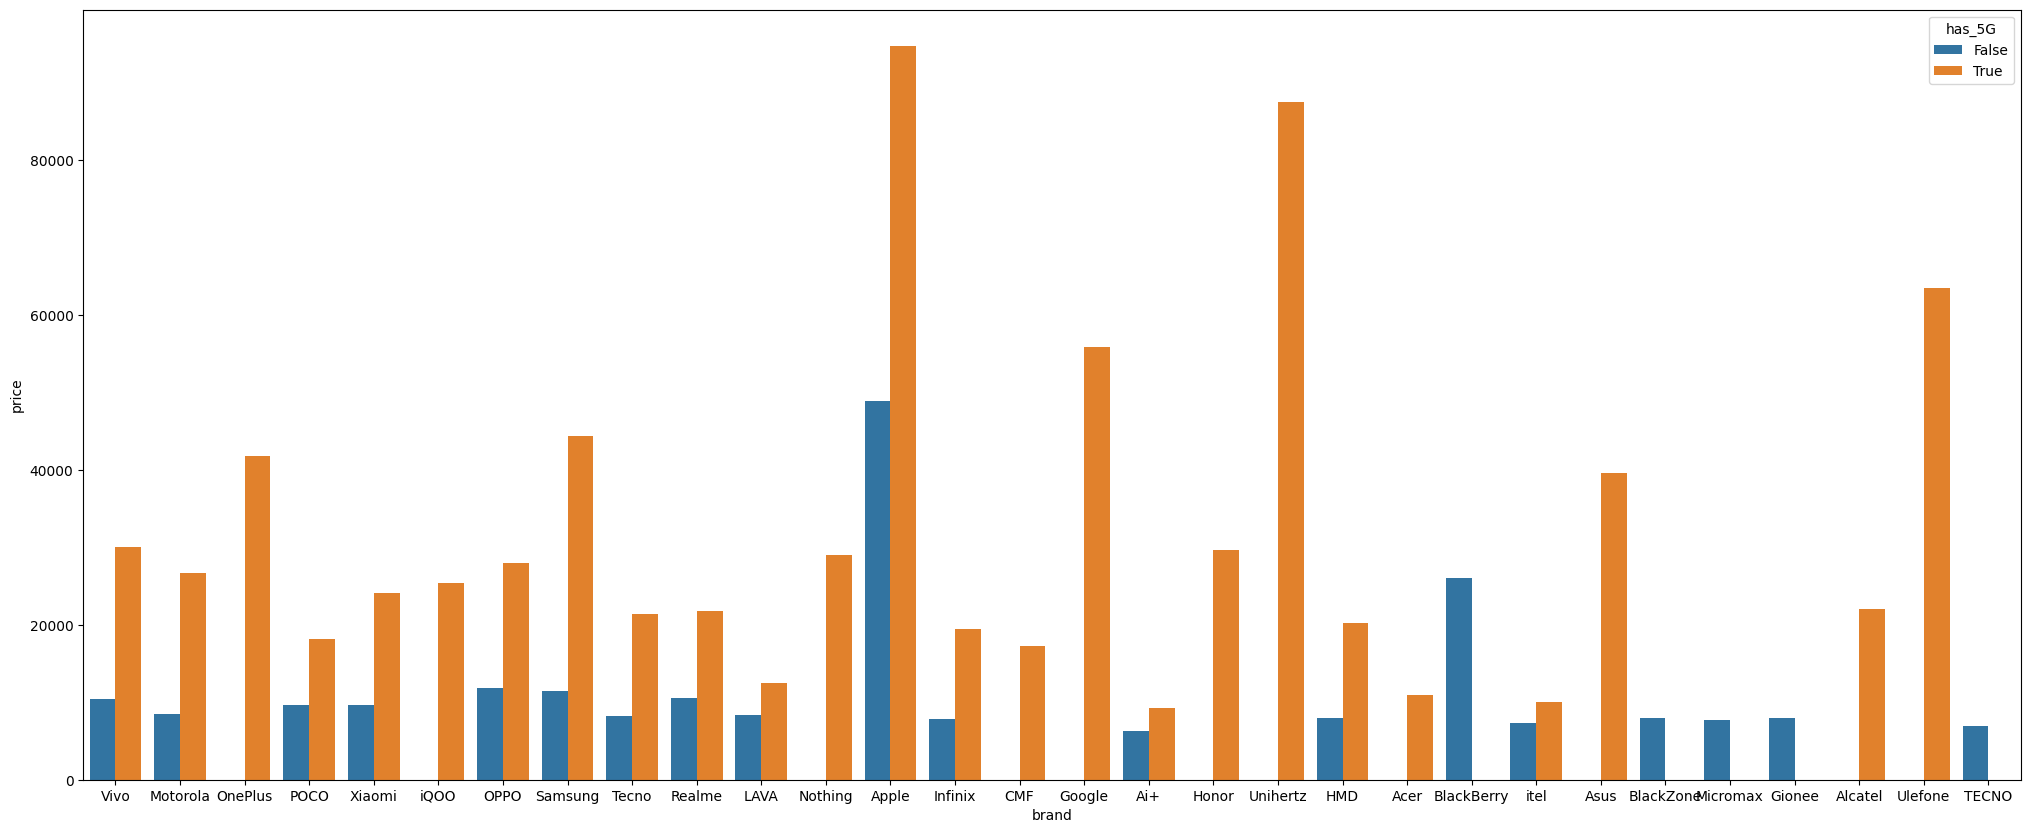

In [153]:
plt.figure(figsize=(25,10))
sns.barplot(data = df1, x='brand',y='price',hue='has_5G',errorbar = None)

**Question:-**
1. compare price, brand, mobile_processor, is_folded columns
- only vivo, techno, samsung and google are brands have folded phones and average price for folded phones is more than 75000 rs
- mobile processor are used in this phones are:- snapdragon, exynos, Dimensty, Tensor

<Axes: xlabel='brand', ylabel='price'>

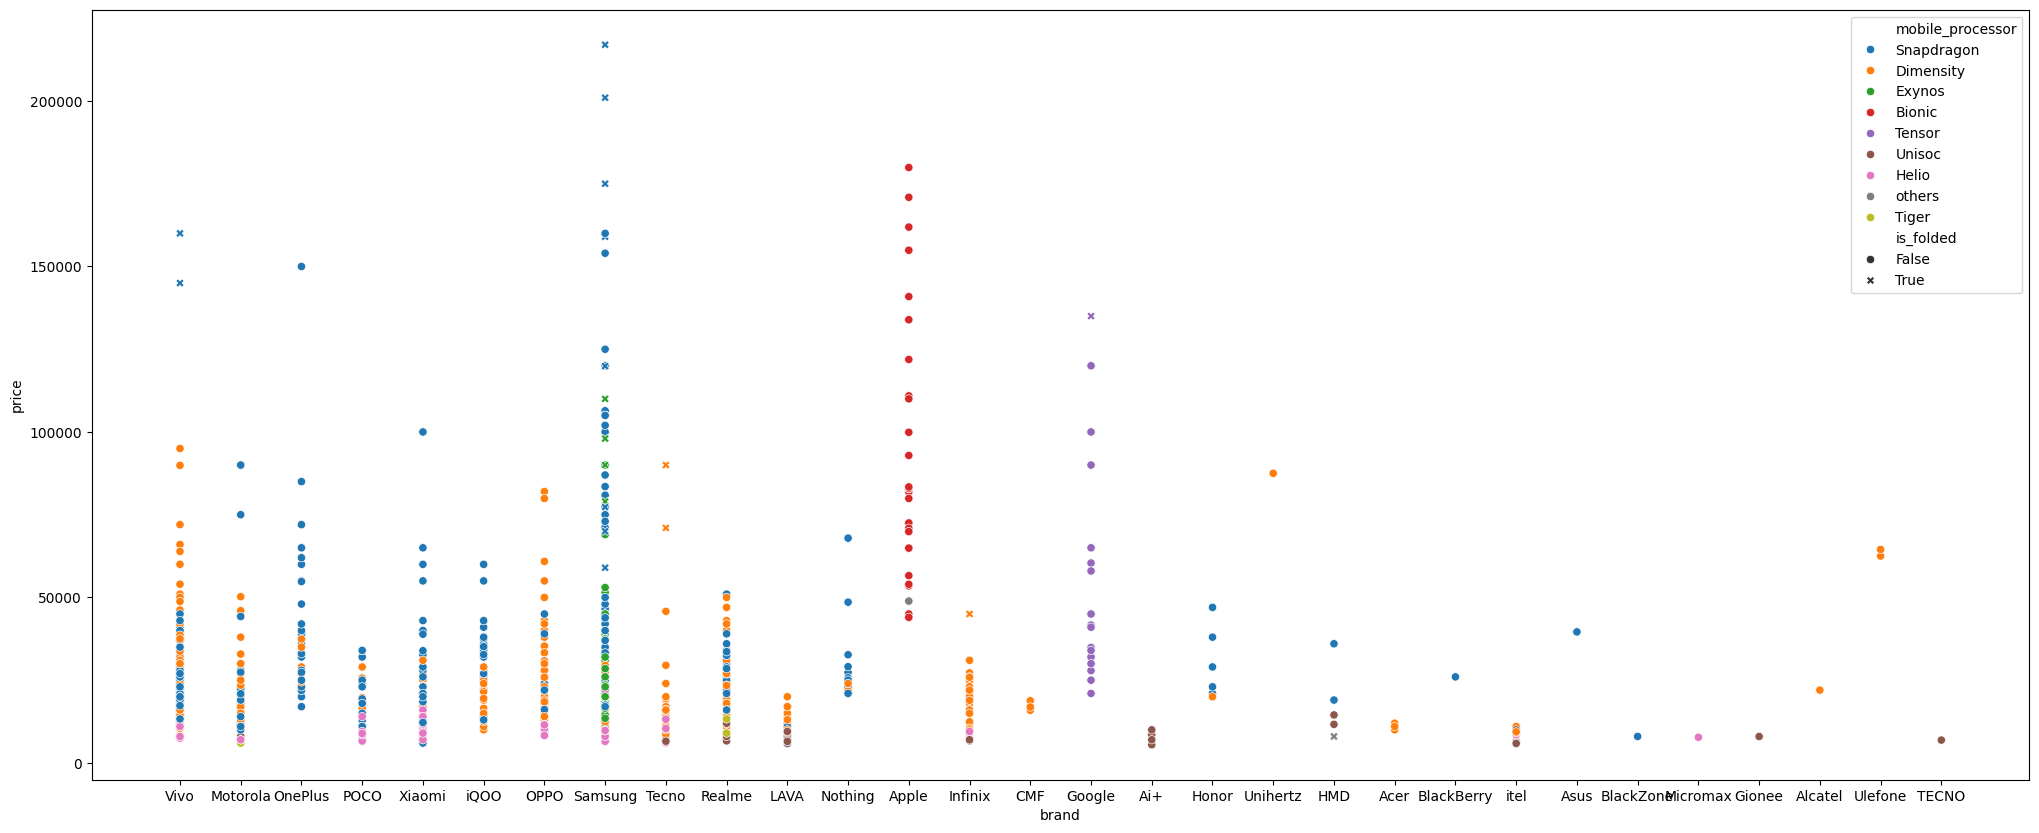

In [154]:
plt.figure(figsize=(25,10))
sns.scatterplot(data=df1,x='brand',y='price',hue='mobile_processor',style='is_folded')

**Question:-**
1. comapare price,brand,core and is_folded
- all folded phones are made with octa core and they are all android.

<Axes: xlabel='brand', ylabel='price'>

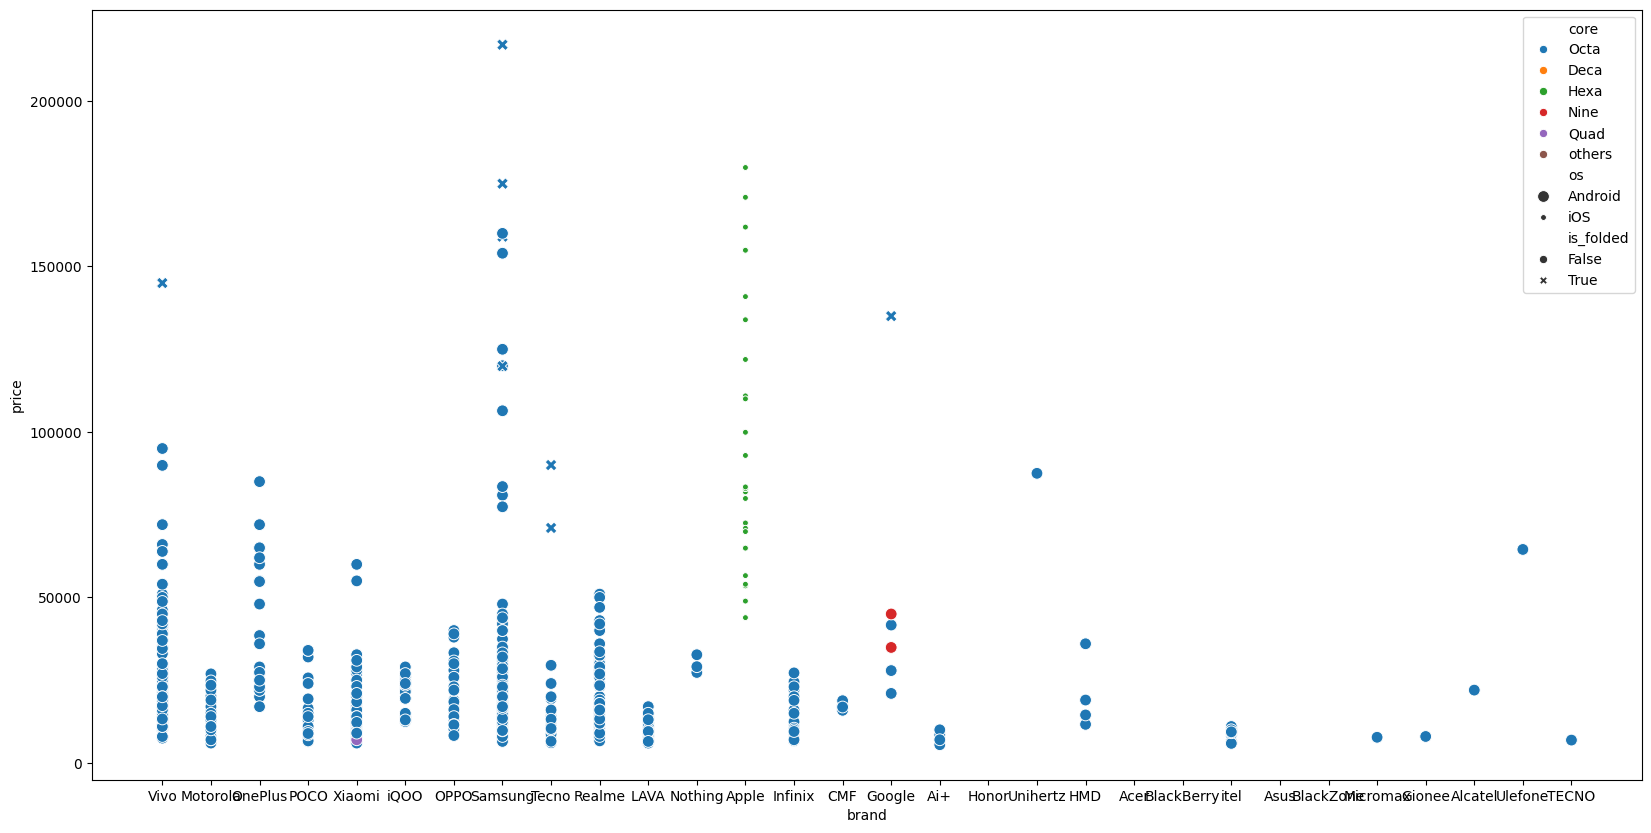

In [155]:
plt.figure(figsize=(20,10))
sns.scatterplot(data=df1,x='brand',y='price',hue='core',style='is_folded',size='os')

<Axes: xlabel='brand', ylabel='price'>

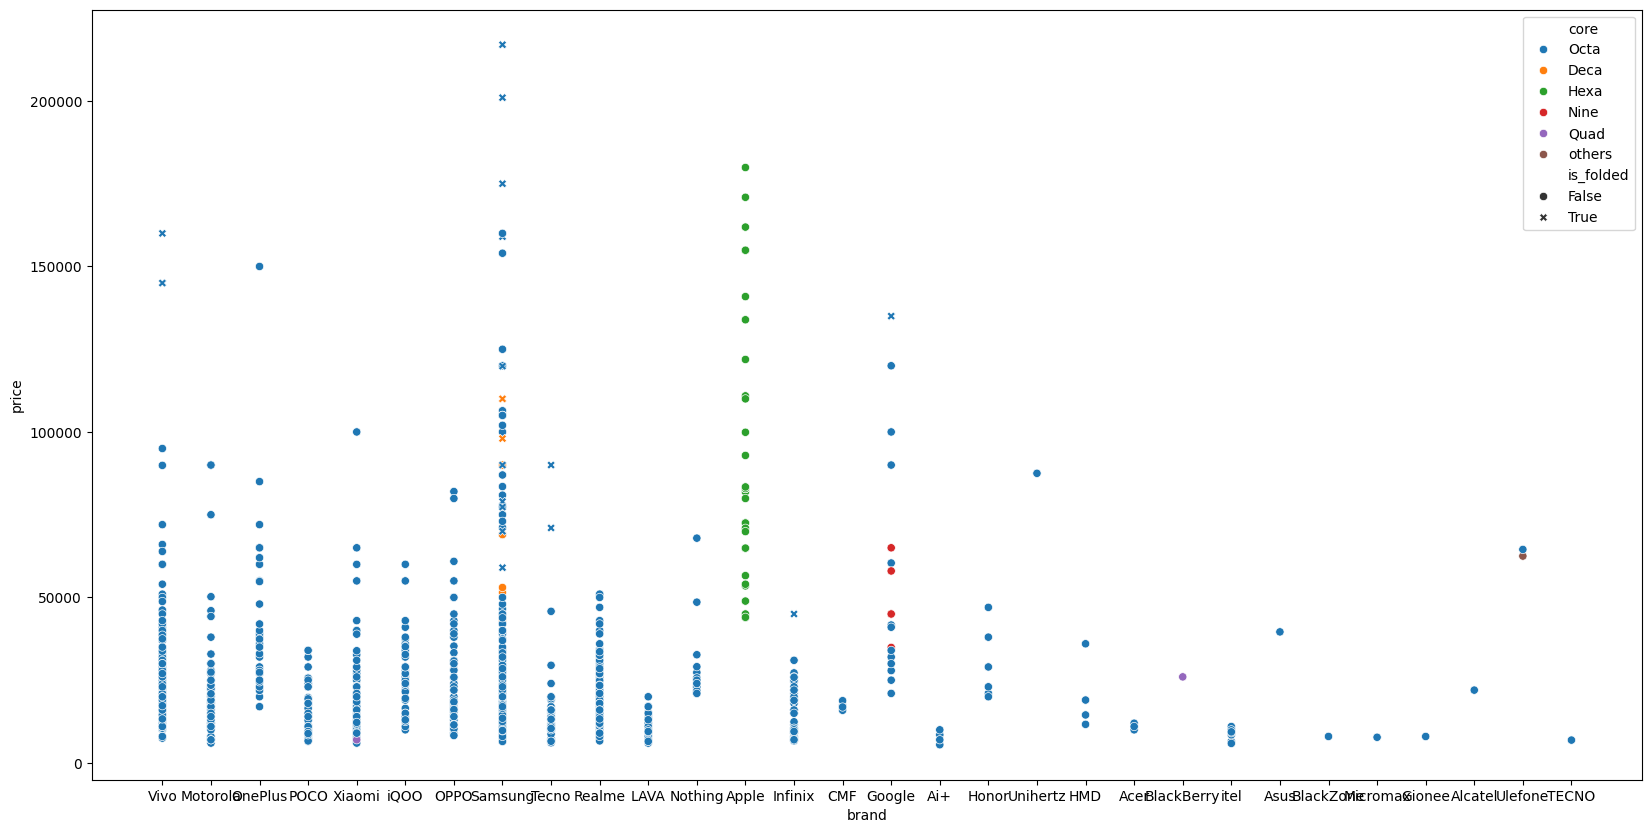

In [156]:
plt.figure(figsize=(20,10))
sns.scatterplot(data=df1,x='brand',y='price',hue ='core',style='is_folded')

**Question:-**
1. how does phone size is affected on folded and non folded phones?
-  all folded phones are having size greater than 7 inch

### Model Building


In [157]:
df1.head()

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
0,Vivo V60,36999,Android,Vivo,Snapdragon,Octa,2.80,8,128.0,6500.0,90.0,6.77,120.0,True,50.0,3,False
1,Motorola Moto G86 Power,17999,Android,Motorola,Dimensity,Octa,2.60,8,128.0,6720.0,33.0,6.70,120.0,True,32.0,2,False
2,OnePlus Nord CE 5,24998,Android,OnePlus,Dimensity,Octa,3.35,8,128.0,7100.0,80.0,6.77,120.0,True,16.0,2,False
3,Poco M7 Plus,13999,Android,POCO,Snapdragon,Octa,2.30,6,128.0,7000.0,33.0,6.90,144.0,True,8.0,1,False
4,Xiaomi Redmi Note 14 SE,14999,Android,Xiaomi,Dimensity,Octa,2.50,6,128.0,5110.0,45.0,6.67,120.0,True,20.0,3,False


In [158]:
# Convert boolean columns back from object to bool
df1['has_5G'] = df1['has_5G'].astype(bool)
df1['is_folded'] = df1['is_folded'].astype(bool)

# Check final structure
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   phone_name                 934 non-null    object 
 1   price                      934 non-null    int64  
 2   os                         665 non-null    object 
 3   brand                      934 non-null    object 
 4   mobile_processor           934 non-null    object 
 5   core                       931 non-null    object 
 6   gigahertz                  832 non-null    float64
 7   RAM                        934 non-null    int64  
 8   ROM                        931 non-null    float64
 9   battery_in_mAh             933 non-null    float64
 10  charging_support_in_watt   877 non-null    float64
 11  size_in_inch               934 non-null    float64
 12  refresh_rate               842 non-null    float64
 13  has_5G                     934 non-null    bool   

# Building Machine Learning Model

- Categorical features like brand, operating system, processor type, and phone model were transformed into numerical form using one-hot encoding so that the machine learning model could understand them. These encoded features were combined with the numerical and boolean features, and the dataset was split into training and testing sets to evaluate the model’s performance. To ensure all features contributed fairly, numerical values were scaled using StandardScaler. A Random Forest Regressor was then trained on the processed data, and its predictions were evaluated using metrics like MAE, MSE, and R² score. Finally, a user-friendly Streamlit web application was developed, allowing users to input smartphone specifications and instantly receive an estimated price. The trained model and scaling parameters were saved using pickle so the system could make predictions in real time.

In [159]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   phone_name                 934 non-null    object 
 1   price                      934 non-null    int64  
 2   os                         665 non-null    object 
 3   brand                      934 non-null    object 
 4   mobile_processor           934 non-null    object 
 5   core                       931 non-null    object 
 6   gigahertz                  832 non-null    float64
 7   RAM                        934 non-null    int64  
 8   ROM                        931 non-null    float64
 9   battery_in_mAh             933 non-null    float64
 10  charging_support_in_watt   877 non-null    float64
 11  size_in_inch               934 non-null    float64
 12  refresh_rate               842 non-null    float64
 13  has_5G                     934 non-null    bool   

In [160]:
df1.head()

,phone_name,price,os,brand,mobile_processor,core,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded
0,Vivo V60,36999,Android,Vivo,Snapdragon,Octa,2.80,8,128.0,6500.0,90.0,6.77,120.0,True,50.0,3,False
1,Motorola Moto G86 Power,17999,Android,Motorola,Dimensity,Octa,2.60,8,128.0,6720.0,33.0,6.70,120.0,True,32.0,2,False
2,OnePlus Nord CE 5,24998,Android,OnePlus,Dimensity,Octa,3.35,8,128.0,7100.0,80.0,6.77,120.0,True,16.0,2,False
3,Poco M7 Plus,13999,Android,POCO,Snapdragon,Octa,2.30,6,128.0,7000.0,33.0,6.90,144.0,True,8.0,1,False
4,Xiaomi Redmi Note 14 SE,14999,Android,Xiaomi,Dimensity,Octa,2.50,6,128.0,5110.0,45.0,6.67,120.0,True,20.0,3,False


### now checking for nominal and ordinal data :-

In [161]:
df1.shape

(934, 17)

In [162]:
# balancing rare categories without removing them

df1['brand'] = df1['brand'].str.strip().str.lower()
threshold = 15

counts = df1['brand'].value_counts()

df1['brand'] = df1['brand'].where(df1['brand'].map(counts) >= threshold, 'other')
df1['brand'].value_counts()

brand
samsung     147
realme      131
vivo        123
xiaomi       77
oppo         71
motorola     56
poco         45
iqoo         41
other        41
infinix      38
oneplus      35
tecno        35
apple        31
lava         30
google       18
nothing      15
Name: count, dtype: int64

In [163]:
# balancing rare categories without removing them 

df1['mobile_processor'] = df1['mobile_processor'].where(
    df1['mobile_processor'].map(df1['mobile_processor'].value_counts()) >= 10,
    'other'
)
df1['mobile_processor'].value_counts()
df1['mobile_processor'] = df1['mobile_processor'].str.lower()

In [164]:
# replacing null value or zero with mode value of camera columns

df1['rear_camera']=df1['rear_camera'].replace(0,2)
df1['rear_camera'].value_counts()

rear_camera
2    415
3    347
1    172
Name: count, dtype: int64

In [165]:
df1['os'].value_counts()

os
Android    636
iOS         29
Name: count, dtype: int64

In [166]:
df1['core'].value_counts()

core
Octa      883
Hexa       31
Deca        9
Nine        5
Quad        2
others      1
Name: count, dtype: int64

### Nominal Data :-
1. os
2. brand
3. mobile_processsor

### Ordinal Data:-
1. core
2. rear_camera


### Boolien Data:- 
1. has 5g
2. is_folded

### Action on data:-
1. removing phone name column.. beacause it is unnecassary at this time
2. and again droppping os column... because it has very large missing values and one category like andoroid is dominating
3. and also dropping core column  becuase the octa core category is dominating with 92% of values
4. need to convert booliean columns into int for better clarification


In [167]:
df1.drop(columns=['phone_name','os','core'],inplace = True)

In [168]:
df1['has_5G'] = df1['has_5G'].astype(int)
df1['is_folded'] = df1['is_folded'].astype(int)

In [169]:
df1.isnull().sum()

price                          0
brand                          0
mobile_processor               0
gigahertz                    102
RAM                            0
ROM                            3
battery_in_mAh                 1
charging_support_in_watt      57
size_in_inch                   0
refresh_rate                  92
has_5G                         0
front_camera_in_megapixel     33
rear_camera                    0
is_folded                      0
dtype: int64

In [170]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      934 non-null    int64  
 1   brand                      934 non-null    object 
 2   mobile_processor           934 non-null    object 
 3   gigahertz                  832 non-null    float64
 4   RAM                        934 non-null    int64  
 5   ROM                        931 non-null    float64
 6   battery_in_mAh             933 non-null    float64
 7   charging_support_in_watt   877 non-null    float64
 8   size_in_inch               934 non-null    float64
 9   refresh_rate               842 non-null    float64
 10  has_5G                     934 non-null    int64  
 11  front_camera_in_megapixel  901 non-null    float64
 12  rear_camera                934 non-null    int64  
 13  is_folded                  934 non-null    int64  

In [1]:
# but before creating we are filling null values of required columns
df1['gigahertz'].fillna(df1['gigahertz'].median(), inplace=True)
df1['front_camera_in_megapixel'].fillna(df1['front_camera_in_megapixel'].median(), inplace=True)



# creating new features from the existing data
# getting new column as performance score because the price of phone is mainly depend uopon performance
df1['performance_score'] = df1['RAM'] * df1['gigahertz']

# also the both camera are useful 
df1['camera_score'] = df1['rear_camera'] + df1['front_camera_in_megapixel']

# again specifing processor
def processor_level(processor):
    if 'snapdragon' in processor or 'tensor' in processor:
        return 'high'
    elif 'dimensity' in processor or 'exynos' in processor:
        return 'mid'
    else:
        return 'low'

df1['processor_tier'] = df1['mobile_processor'].apply(processor_level)

In [172]:
df1.head()

,price,brand,mobile_processor,gigahertz,RAM,ROM,battery_in_mAh,charging_support_in_watt,size_in_inch,refresh_rate,has_5G,front_camera_in_megapixel,rear_camera,is_folded,performance_score,camera_score,processor_tier
0,36999,vivo,snapdragon,2.80,8,128.0,6500.0,90.0,6.77,120.0,1,50.0,3,0,22.4,53.0,high
1,17999,motorola,dimensity,2.60,8,128.0,6720.0,33.0,6.70,120.0,1,32.0,2,0,20.8,34.0,mid
2,24998,oneplus,dimensity,3.35,8,128.0,7100.0,80.0,6.77,120.0,1,16.0,2,0,26.8,18.0,mid
3,13999,poco,snapdragon,2.30,6,128.0,7000.0,33.0,6.90,144.0,1,8.0,1,0,13.8,9.0,high
4,14999,xiaomi,dimensity,2.50,6,128.0,5110.0,45.0,6.67,120.0,1,20.0,3,0,15.0,23.0,mid


In [173]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      934 non-null    int64  
 1   brand                      934 non-null    object 
 2   mobile_processor           934 non-null    object 
 3   gigahertz                  934 non-null    float64
 4   RAM                        934 non-null    int64  
 5   ROM                        931 non-null    float64
 6   battery_in_mAh             933 non-null    float64
 7   charging_support_in_watt   877 non-null    float64
 8   size_in_inch               934 non-null    float64
 9   refresh_rate               842 non-null    float64
 10  has_5G                     934 non-null    int64  
 11  front_camera_in_megapixel  934 non-null    float64
 12  rear_camera                934 non-null    int64  
 13  is_folded                  934 non-null    int64  

In [174]:
df1.isnull().sum()

price                         0
brand                         0
mobile_processor              0
gigahertz                     0
RAM                           0
ROM                           3
battery_in_mAh                1
charging_support_in_watt     57
size_in_inch                  0
refresh_rate                 92
has_5G                        0
front_camera_in_megapixel     0
rear_camera                   0
is_folded                     0
performance_score             0
camera_score                  0
processor_tier                0
dtype: int64

In [176]:
# getting important libraries
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,RobustScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,KNNImputer,IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Separate features and target
X = df1.drop('price', axis=1)
y = df1['price']

# sepearing nominal and numerical data 
num_cols = X.select_dtypes(include=['int64','float64']).columns
ohe_cols =['brand','mobile_processor']
ord_cols = ['processor_tier']

ord_enc = OrdinalEncoder(
    categories = [['low','mid','high']]
)

# building pipeline

num_simple_pipe = Pipeline([
    ('imputer',SimpleImputer()),
    ('scaler',RobustScaler())
])

num_knn_pipe = Pipeline([
    ('imputer',KNNImputer()),
    ('scaler',RobustScaler())
])

num_iter_pipe = Pipeline([
    ('imputer',IterativeImputer()),
    ('scaler',RobustScaler())
])

# no need of imputer becuase null value are not present in this column
ord_pipe = Pipeline([
    ('ord_encoder',ord_enc)
])

# again no need of imputer because in categorical columns null values are not present
ohe_pipe = Pipeline([
    ('ohe_encoder',OneHotEncoder(drop='first',handle_unknown = 'ignore',sparse_output = False))
])

transformer = ColumnTransformer([
    # -----replaceble-----------------
    ('num',num_simple_pipe,num_cols),
    # -----------------------------------
    ('ord',ord_pipe,ord_cols),
    ('ohe',ohe_pipe,ohe_cols)
])

pipeline = Pipeline([
    ('preprocess',transformer),
    ('regressor',LinearRegression())
])


# data spliting 
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

param = [
    # for Simple imputer
    {
        'preprocess__num':[num_simple_pipe],
        'preprocess__num__imputer__strategy':['mean','median']
    },

    # for KNN imputer
    {
        'preprocess__num':[num_knn_pipe],
        'preprocess__num__imputer__n_neighbors':[3,5,7]
    },

    # for iterative
    {
        'preprocess__num':[num_iter_pipe],
        'preprocess__num__imputer__estimator':[
            LinearRegression(),
            DecisionTreeRegressor(random_state = 42)
        ]
    }
]

gs = GridSearchCV(
    estimator = pipeline,
    param_grid= param,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [177]:
gs.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocess__num': [Pipeline(step...ustScaler())])], 'preprocess__num__imputer__strategy': ['mean', 'median']}, {'preprocess__num': [Pipeline(step...ustScaler())])], 'preprocess__num__imputer__n_neighbors': [3, 5, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intContr

In [178]:
print(gs.best_params_)

{'preprocess__num': Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', RobustScaler())]), 'preprocess__num__imputer__strategy': 'mean'}


In [179]:
# checking score
print('testing score is: ',gs.best_score_)

testing score is:  0.8367608416720153


In [180]:
y_pred = gs.best_estimator_.predict(X_train)
print('traning score is:  ',r2_score(y_train,y_pred))


traning score is:   0.8605639069315751


In [181]:
# now making clone for optuna  cause we want new pipeline with previouse parameters
from sklearn.base import clone

base_pipeline = clone(gs.best_estimator_)
base_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [182]:
import optuna
from sklearn.model_selection import cross_val_score

In [183]:
# defining objective function

def objective(trial):
    
    # using multiple models for comparision
    model_name = trial.suggest_categorical('model_name',['DecisionTreeRegressor','RandomForestRegressor','XGBRegressor'])

    if model_name == 'DecisionTreeRegressor':
        model = DecisionTreeRegressor(
            max_depth = trial.suggest_int('max_depth_dt',3,10),
            min_samples_leaf = trial.suggest_int('min_samples_leaf',30,100),
            min_impurity_decrease = trial.suggest_float('min_impurity_decrease_dt',0.001,0.02),
            max_features= trial.suggest_categorical('max_features_dt',[None, 'sqrt', 'log2'])
        )
    elif model_name == 'RandomForestRegressor':
        model = RandomForestRegressor(
            n_estimators = trial.suggest_int('n_estimators_rf',50,200),
            max_depth = trial.suggest_int('max_depth_rf',3,10),
            min_impurity_decrease = trial.suggest_float('min_impurity_decrease_rf',0.001,0.02),
            max_features= trial.suggest_categorical('max_features_rf',[None, 'sqrt', 'log2'])
        )

    else: 
        model= XGBRegressor(
            n_estimators = trial.suggest_int('n_estimators_xgb',50,200),
            max_depth = trial.suggest_int('max_depth_xgb',3,10),
            min_child_weight = trial.suggest_int('min_child_weight',3,10),
            gamma = trial.suggest_float('gamma',0.01,0.3),
            subsample = trial.suggest_float('subsample',0.5,1),
            colsample_bytree = trial.suggest_float('colsample_bytree',0.5,1),
            learning_rate = trial.suggest_float('learning_rate',0.01,0.2),
            reg_alpha = trial.suggest_float('reg_alpha',0.1,0.3),
            reg_lambda = trial.suggest_float('reg_lambda',0.01,0.2)
        )

    # again makoing clone of base pipeline to get fresh daata for the model
    new_pipeline = clone(base_pipeline)
    # setting model in new pipeline 
    new_pipeline.set_params(
        regressor = model
    )

    # performing cross validaion
    scores = cross_val_score(
        new_pipeline,
        X_train,
        y_train,
        scoring = 'r2',
        n_jobs = -1
    )

    return scores.mean()

In [184]:
study = optuna.create_study(direction = 'maximize')
study.optimize(objective,n_trials = 30)

[I 2026-04-21 15:43:20,101] A new study created in memory with name: no-name-a9d9bf6a-c9fc-4ebb-91d8-49c8b13c9783
[I 2026-04-21 15:43:20,665] Trial 0 finished with value: 0.8556297540117477 and parameters: {'model_name': 'RandomForestRegressor', 'n_estimators_rf': 171, 'max_depth_rf': 5, 'min_impurity_decrease_rf': 0.01002545324036955, 'max_features_rf': None}. Best is trial 0 with value: 0.8556297540117477.
[I 2026-04-21 15:43:20,726] Trial 1 finished with value: 0.4328583695191486 and parameters: {'model_name': 'DecisionTreeRegressor', 'max_depth_dt': 7, 'min_samples_leaf': 51, 'min_impurity_decrease_dt': 0.00809808957450826, 'max_features_dt': 'log2'}. Best is trial 0 with value: 0.8556297540117477.
[I 2026-04-21 15:43:21,182] Trial 2 finished with value: 0.8771965668398076 and parameters: {'model_name': 'RandomForestRegressor', 'n_estimators_rf': 113, 'max_depth_rf': 8, 'min_impurity_decrease_rf': 0.0038094278456449675, 'max_features_rf': None}. Best is trial 2 with value: 0.877196

In [187]:
print(study.best_trial.params)

{'model_name': 'XGBRegressor', 'n_estimators_xgb': 119, 'max_depth_xgb': 6, 'min_child_weight': 3, 'gamma': 0.0924736383373788, 'subsample': 0.6428983446692714, 'colsample_bytree': 0.7138250088442608, 'learning_rate': 0.10873133270059128, 'reg_alpha': 0.10447209977913953, 'reg_lambda': 0.05299555391404104}


In [188]:
print(study.best_trial.value)

0.879535686969757


In [205]:
# defiining final model

final_model = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    min_child_weight=4,
    gamma=0.1,
    subsample=0.65,
    colsample_bytree=0.7,
    learning_rate=0.05,
    reg_alpha=0.3,
    reg_lambda=0.3,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1
)


final_pipeline = clone(base_pipeline)
final_pipeline.set_params(
        regressor = final_model
    )

final_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [206]:
y_predd = final_pipeline.predict(X_test)
print('r2_score is: ',r2_score(y_test,y_predd))

r2_score is:  0.9331521391868591


In [207]:
# checking adjusted r2_score
n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (1 - 0.9245) * (n - 1) / (n - p - 1)
print("Adjusted R2:", adj_r2)

Adjusted R2: 0.9173941176470588


In [208]:
# checking for overfitting

print("Train:", final_pipeline.score(X_train, y_train))
print("Test :", final_pipeline.score(X_test, y_test))

Train: 0.9761479496955872
Test : 0.9331521391868591


In [200]:
# so the gap between r2 score and adjusted r2 score is very less 
# so the newly creaated feature are seems to be important 

In [201]:
# checking feature importance
features = final_pipeline.named_steps['preprocess'].get_feature_names_out()
importance = final_pipeline.named_steps['regressor'].feature_importances_

fi = pd.DataFrame({
    'features': features,
    'importance': importance
})

fi

,features,importance
0,num__gigahertz,0.145604
1,num__RAM,0.040546
2,num__ROM,0.107930
3,num__battery_in_mAh,0.031390
4,num__charging_support_in_watt,0.030024
5,num__size_in_inch,0.044513
6,num__refresh_rate,0.040496
7,num__has_5G,0.014769
8,num__front_camera_in_megapixel,0.048940
9,num__rear_camera,0.014154


In [202]:
# now there are lots for columns are presents who have very less feature importance...
# at this piont i am doing manual threshold filtering

# getting those feature who have feature importance more than 0.003
new_fi = fi[fi['importance'] >= 0.003]
new_fi

,features,importance
0,num__gigahertz,0.145604
1,num__RAM,0.040546
2,num__ROM,0.107930
3,num__battery_in_mAh,0.031390
4,num__charging_support_in_watt,0.030024
5,num__size_in_inch,0.044513
6,num__refresh_rate,0.040496
7,num__has_5G,0.014769
8,num__front_camera_in_megapixel,0.048940
9,num__rear_camera,0.014154


In [214]:
# now dumping final model
import pickle

with open('final_pipeline.pkl', 'wb') as f:
    pickle.dump((final_pipeline, X_train.columns), f)

